# Guide: Periodograms of Keplerian signals

Often the first step in identifying a companion to a star from time series data is to find or test trial orbital periods by computing a periodogram of the data. A periodogram is a measure of the "power" of a signal as a function of frequency or period. For irregularly spaced data (nearly always the case), a common periodogram choice is the [Lomb-Scargle periodogram](https://docs.astropy.org/en/stable/timeseries/lombscargle.html), which computes the log-likelihood of a sinusoidal model fitted to the data on a grid of trial frequencies. This approach is fast because the model is linear in the other parameters (amplitudes of sin and cos terms), and the log-likelihood can be computed analytically (typically taken to be the maximum log-likelihood over the linear parameters). For eccentric orbits, the signal is not sinusoidal, but multi-term or multi-harmonic periodograms can often perform well enough to detect the signal.

An alternative approach for handling eccentric or more general orbital signals is to use a "Keplerian periodogram" (e.g., [Baluev 2014](https://arxiv.org/abs/1409.6115)) or other nonlinear periodograms. 
These approaches can be more correct but are often much slower than Lomb–Scargle because the models are nonlinear in the parameters. 

`harv` contains functionality for computing linear, Lomb–Scargle-like periodograms of any of the data types supported by the package (radial velocity, Gaia astrometry, etc.). 
In addition to the classic Lomb-Scargle approach, which maximizes the log-likelihood of the linear parameters at every trial period, we also provide a periodogram that instead marginalizes over the amplitude terms under a prior. 
If we choose the prior to be Gaussian, then the marginalization can be done analytically, and the log-likelihood can be computed almost as efficiently as in the Lomb-Scargle case. 
This has two advantages: (1) the periodogram power is a marginal log-likelihood rather than a maximum log-likelihood, which can be more robust to overfitting (as we explain later), and (2) the prior can be chosen to build in physical assumptions about the systems you are searching for. 
For example, the prior can be made a function of the orbital period so that the amplitudes of the harmonics are expected to be smaller for longer orbital periods, as we expect from Kepler's third law (at constant masses).

We demonstrate these concepts here and compare to more classical periodograms below. 

Let's start with the imports we'll need:

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

In [2]:
import astropy.units as u
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import quaxed.numpy as jnp
from astropy.table import QTable
from scipy.special import gammainccinv
from unxt import Q, ustrip

import harv
import harv.data as hd
import harv.models as hm
import harv.periodogram as hp
from harv.simulate import simulate_rv_sb1_data

## The Lomb–Scargle case: Maximum likelihood with a single harmonic

We'll start by computing a single-term Lomb–Scargle periodogram of a simulated radial-velocity dataset. 

This periodogram fits a sinusoidal model 

$$
y(t) = a \, \cos(2\pi\nu \, t) + b \, \sin(2\pi\nu \, t) + c
$$

to the data at each trial frequency $\nu = 1/P$ (for period $P$), where $a$ and $b$ are the amplitudes of the cosine and sine terms, and $c$ is a constant offset. The model is linear in the parameters $\boldsymbol{\theta} = (a, b, c)$, so we can solve for the best-fit parameters analytically using a least squares solve at a fixed frequency/period.
The periodogram power is defined to be the improvement (delta log-likelihood) of the best-fit model compared to a constant (base) model at the optimized parameters. 

Here we'll simulate radial velocity data for an eccentric orbit and compute this periodogram:

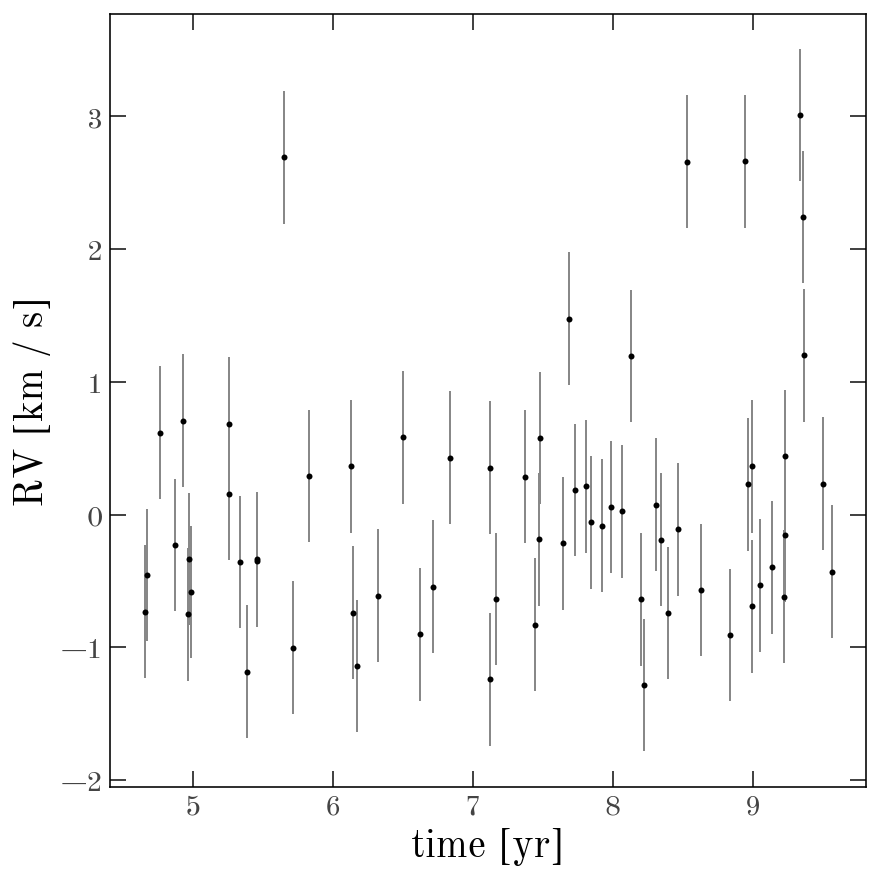

In [3]:
rv_params = {
    "period": Q(150.0, "day"),
    "eccentricity": 0.75,
    "rv_semiamp": Q(2.0, "km/s"),
    "rv_err": Q(0.5, "km/s"),
    "v_sys": Q(0.0, "km/s"),
}
data_1, truth = simulate_rv_sb1_data(seed=42, n_obs=64, **rv_params)

fig, ax = plt.subplots(figsize=(6, 6))
_ = data_1.plot(ax=ax)

To compute the periodogram, we first need to define a grid of trial periods. We can do this in `harv` using the {py:func}`harv.periodogram.frequency_grid` function in `harv.periodogram`. We'll choose a range of periods from 10 to $10^3$ days and sample 16 points per peak in the periodogram. To compute the profile likelihood periodogram (i.e., the maximum likelihood or Lomb–Scargle periodogram), we call the {py:func}`harv.periodogram.periodogram` function with `prior=False`:

In [4]:
P_min, P_max = Q([10.0, 1e3], "day")

grid_samples_per_peak = 16
grid = hp.frequency_grid(
    data_1, period_min=P_min, period_max=P_max, samples_per_peak=grid_samples_per_peak
)
profile_pgram_nterms1 = hp.periodogram(data_1, grid, prior=False, n_terms=1)

Now we visualize the periodogram. We plot the periodogram power, $z(\nu)$, as a function of period using a logarithmic scale for the period axis. The top panel shows the periodogram power (a delta log-likelihood) and the lower panel shows the exponentiated power (a likelihood ratio, normalized to the maximum). 

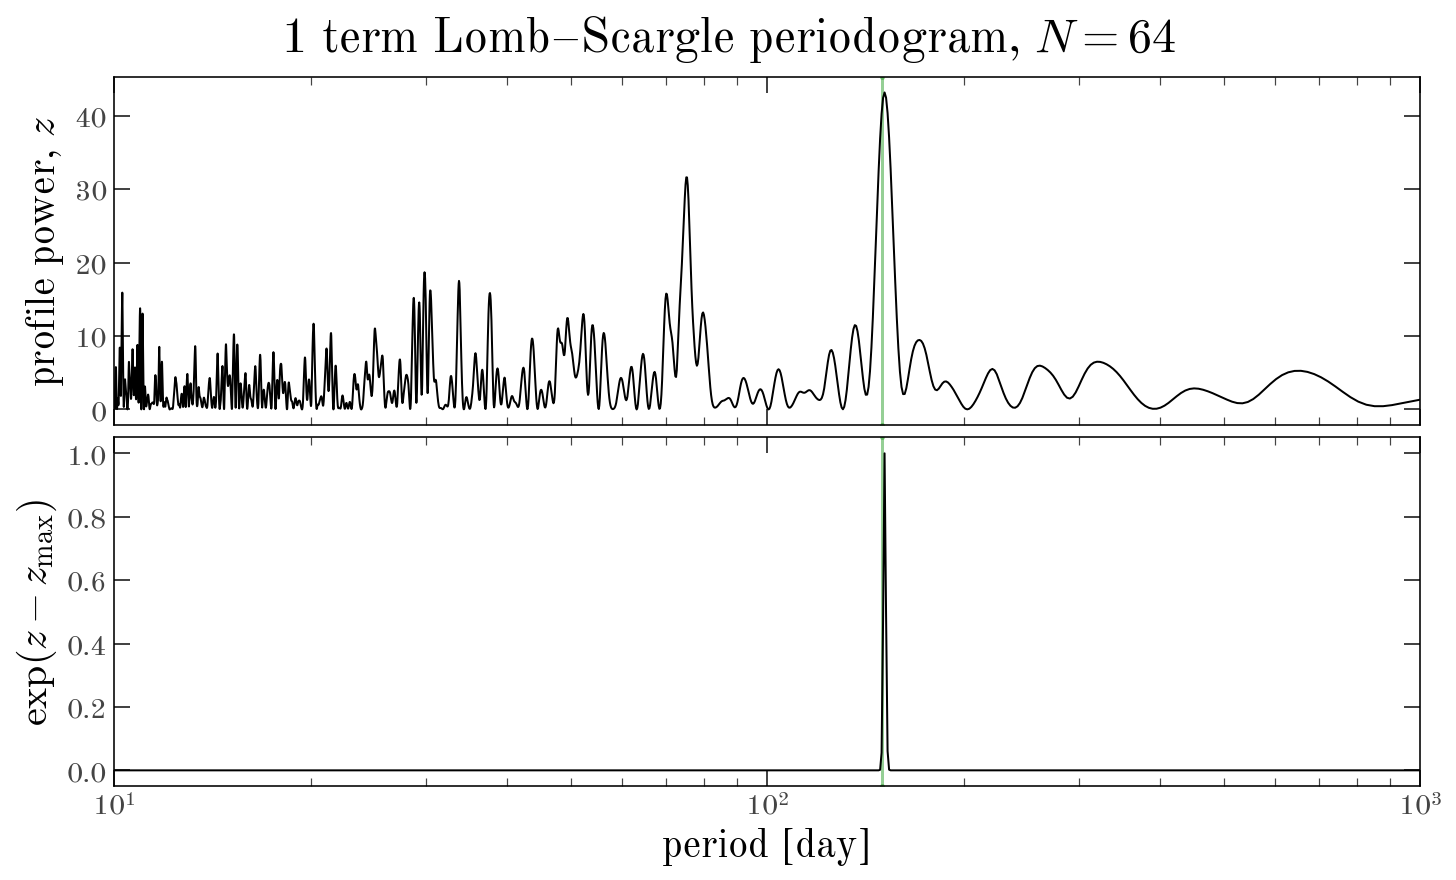

In [5]:
def plot_periodogram(pgram):
    fig, axes = plt.subplots(
        2, 1, figsize=(10, 6), sharex=True, constrained_layout=True
    )

    pgram_P = ustrip("day", pgram.period)

    ax = axes[0]
    ax.plot(
        pgram_P,
        pgram.delta_ln_likelihood,
        marker="",
        lw=1.0,
    )
    _ = ax.set(
        xscale="log",
        ylabel="profile power, $z$",
    )

    ax = axes[1]
    ax.plot(
        ustrip("day", pgram.period),
        jnp.exp(pgram.delta_ln_likelihood - pgram.delta_ln_likelihood.max()),
        marker="",
        lw=1.0,
    )
    _ = ax.set(
        xscale="log",
        xlabel="period [day]",
        ylabel=r"$\exp(z-z_{\max})$",
        xlim=(jnp.min(pgram_P), jnp.max(pgram_P)),
    )

    for ax in axes:
        ax.axvline(
            ustrip("day", truth["period"]),
            color="tab:green",
            ls="-",
            alpha=0.5,
            zorder=-10,
        )

    return fig, axes


fig, _ = plot_periodogram(profile_pgram_nterms1)
_ = fig.suptitle(f"1 term Lomb–Scargle periodogram, $N={data_1.n_times}$", fontsize=24)

From the periodogram above, we can see that there is a clear mode at the true period of the simulated data, so that's good! It's a relatively strong signal (signal-to-noise S/N ~ 32), so that is expected.
The secondary peak near 75 days is at P/2: an eccentric orbit puts power into harmonics of the true period, which is one motivation for trying multi-term models next.

Let's see what the data look like phase-folded at the periodogram peak:

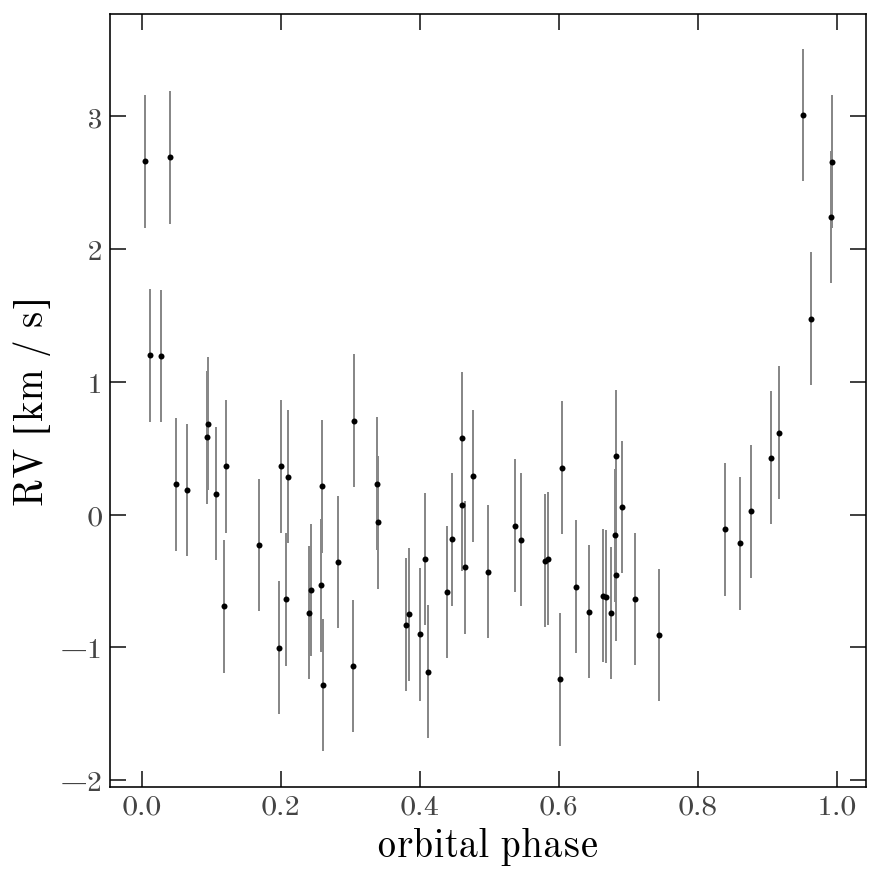

In [6]:
_ = data_1.plot(phase_fold=profile_pgram_nterms1.max_period())

That looks like a reasonable folded signal!

For this system, we know it is eccentric, so we can also see if including more harmonics in the model helps or refines the period. The extra harmonics / terms are often used to capture the eccentricity (still computing a classic Lomb–Scargle / maximum likelihood periodogram). We can do this by setting `n_terms > 1` in the {py:func}`harv.periodogram.periodogram` function. Here we compute a two-term periodogram `n_terms=2`:

In [7]:
profile_pgram_nterms2 = hp.periodogram(data_1, grid, prior=False, n_terms=2)

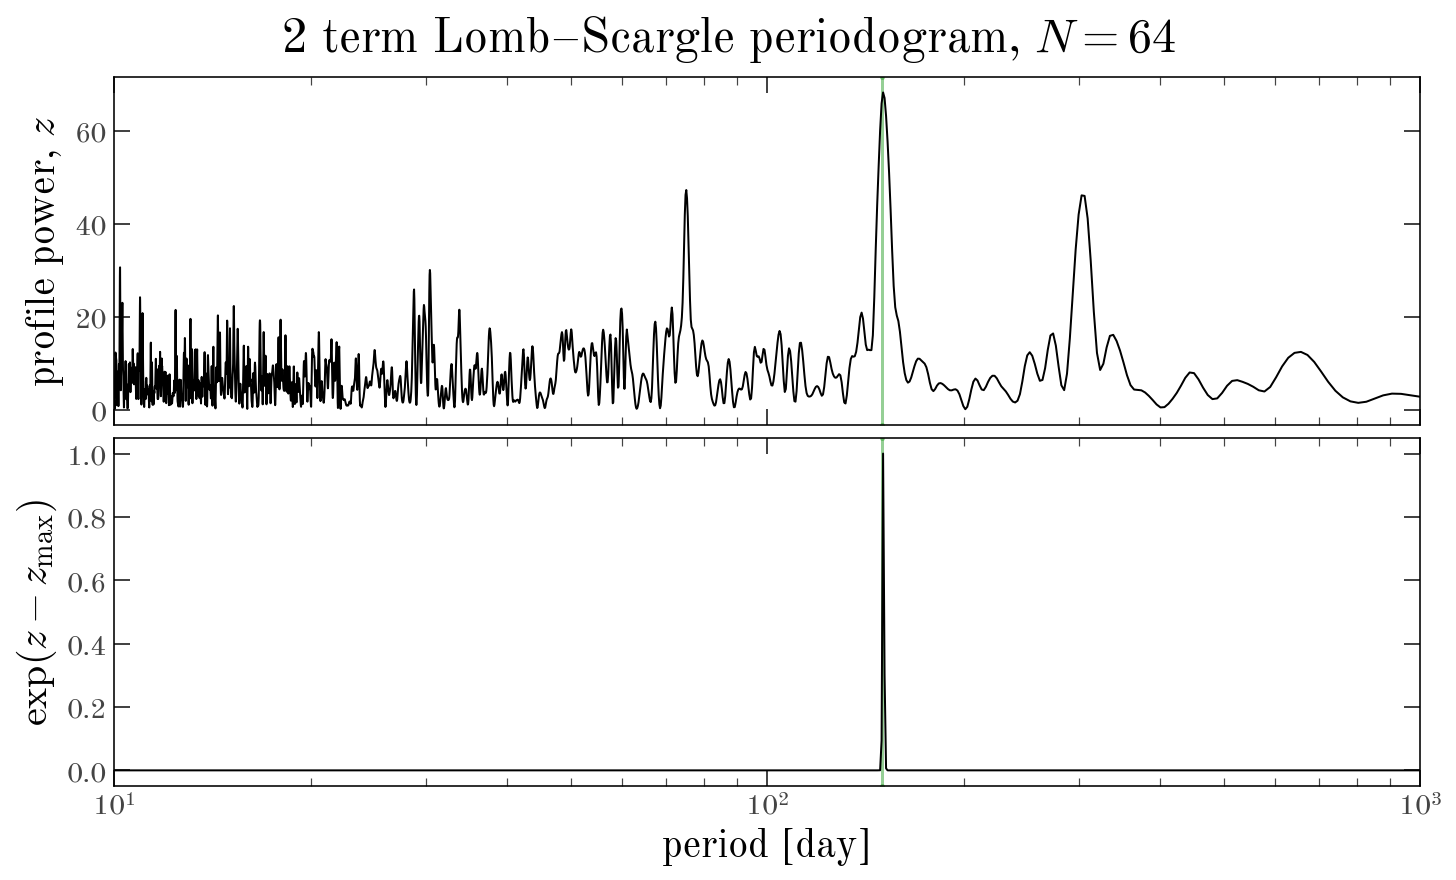

In [8]:
fig, _ = plot_periodogram(profile_pgram_nterms2)
_ = fig.suptitle(f"2 term Lomb–Scargle periodogram, $N={data_1.n_times}$", fontsize=24)

In this case, adding more terms does not really help because the signal is strong and the phase coverage of the data is good. If you look at the periodogram power, the peak does get larger with the `n_terms=2` case, but it is a clear dominant mode in either case. 

What if we had less data? Let's try simulating a dataset with 24 epochs but the same parameters:

In [9]:
data_2, truth = simulate_rv_sb1_data(seed=42, n_obs=24, **rv_params)

We now compute multi-term periodograms of this smaller dataset:

In [10]:
profile_pgrams_2 = {}
for n_terms in [1, 2, 3]:
    profile_pgrams_2[n_terms] = hp.periodogram(
        data_2, grid, prior=False, n_terms=n_terms
    )

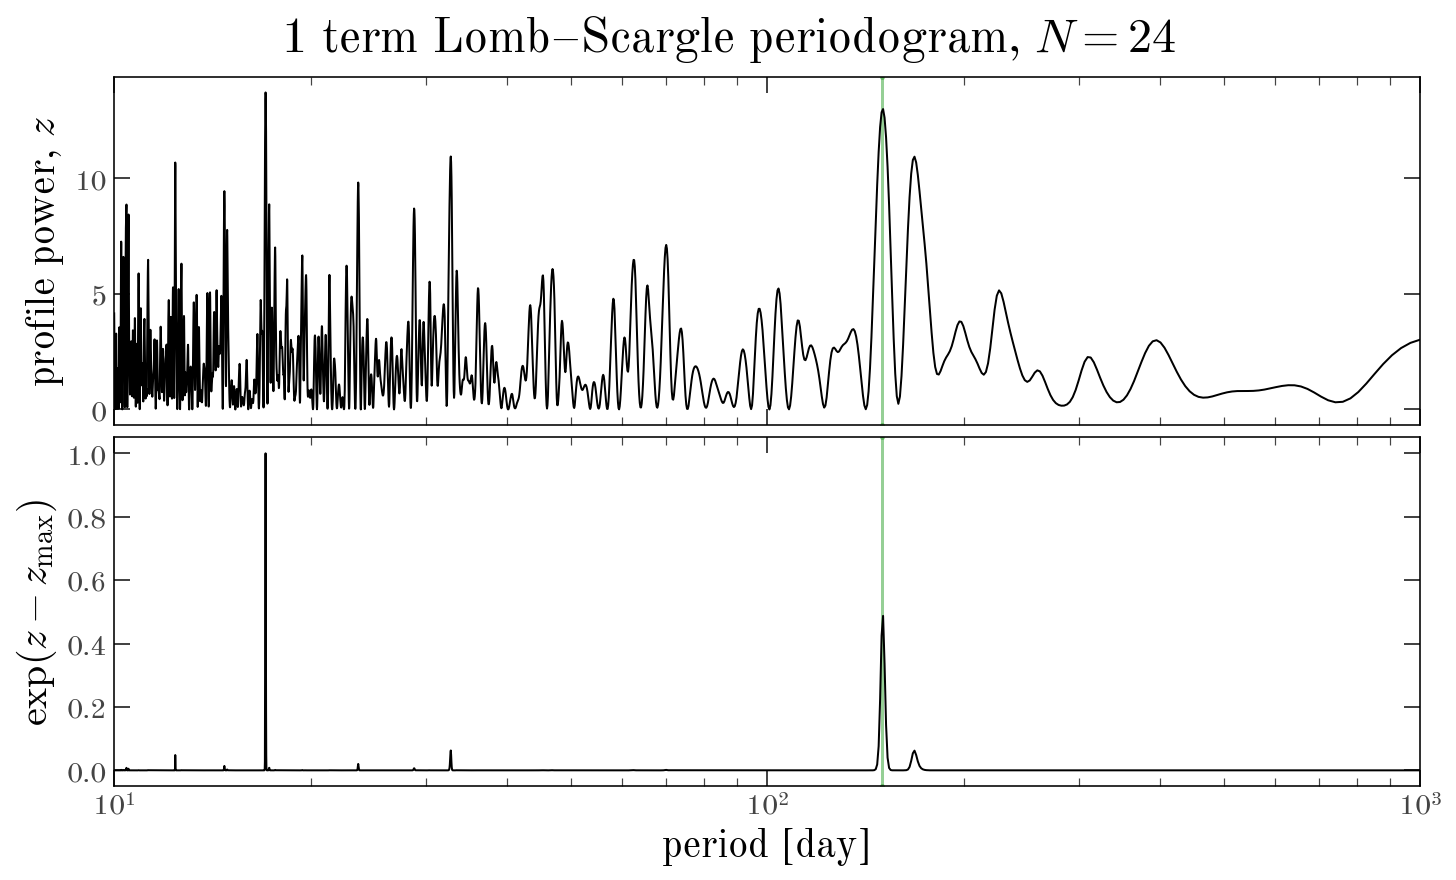

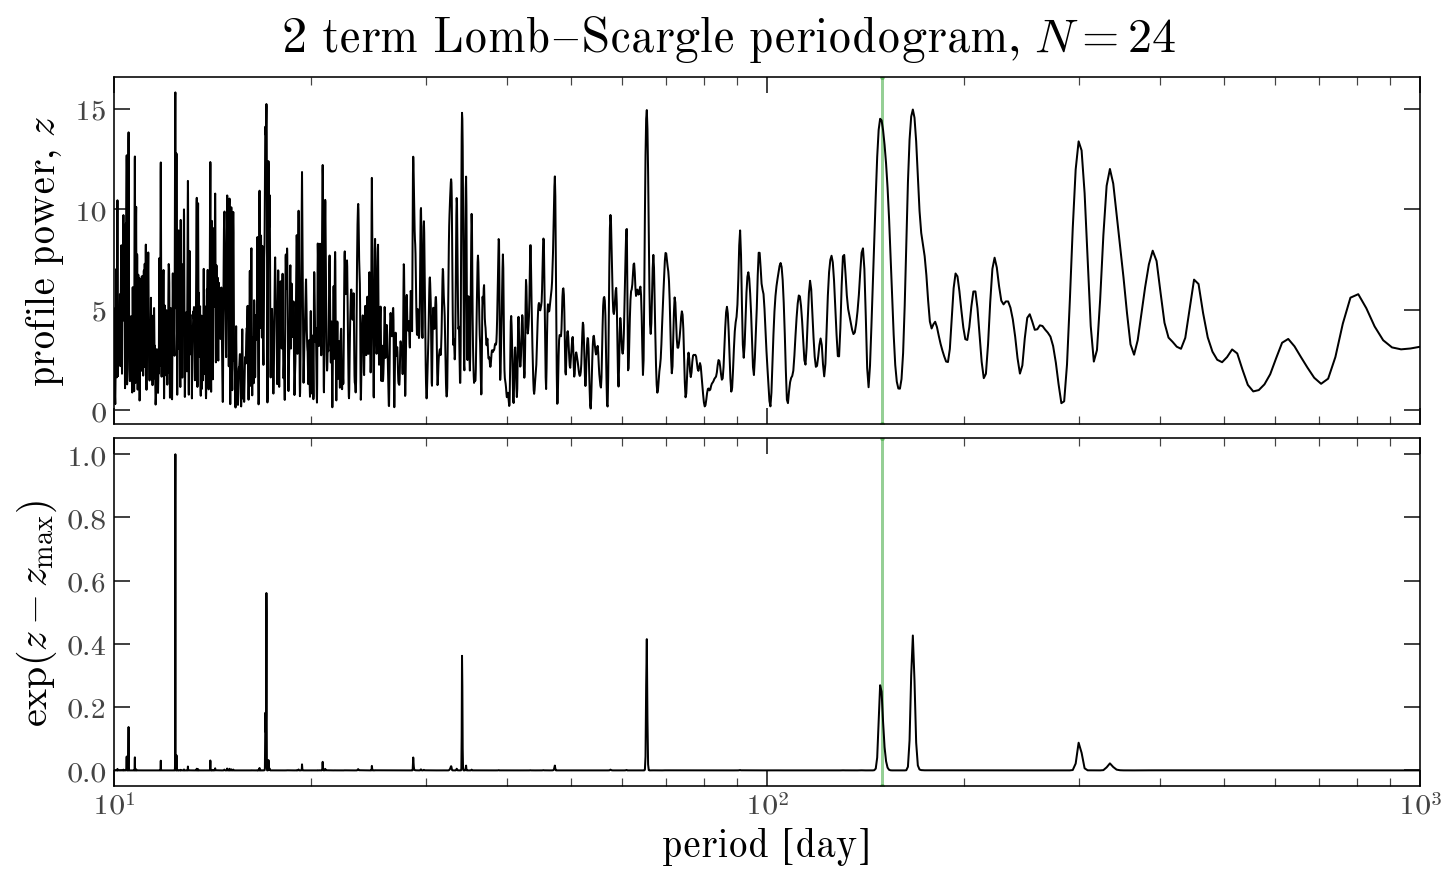

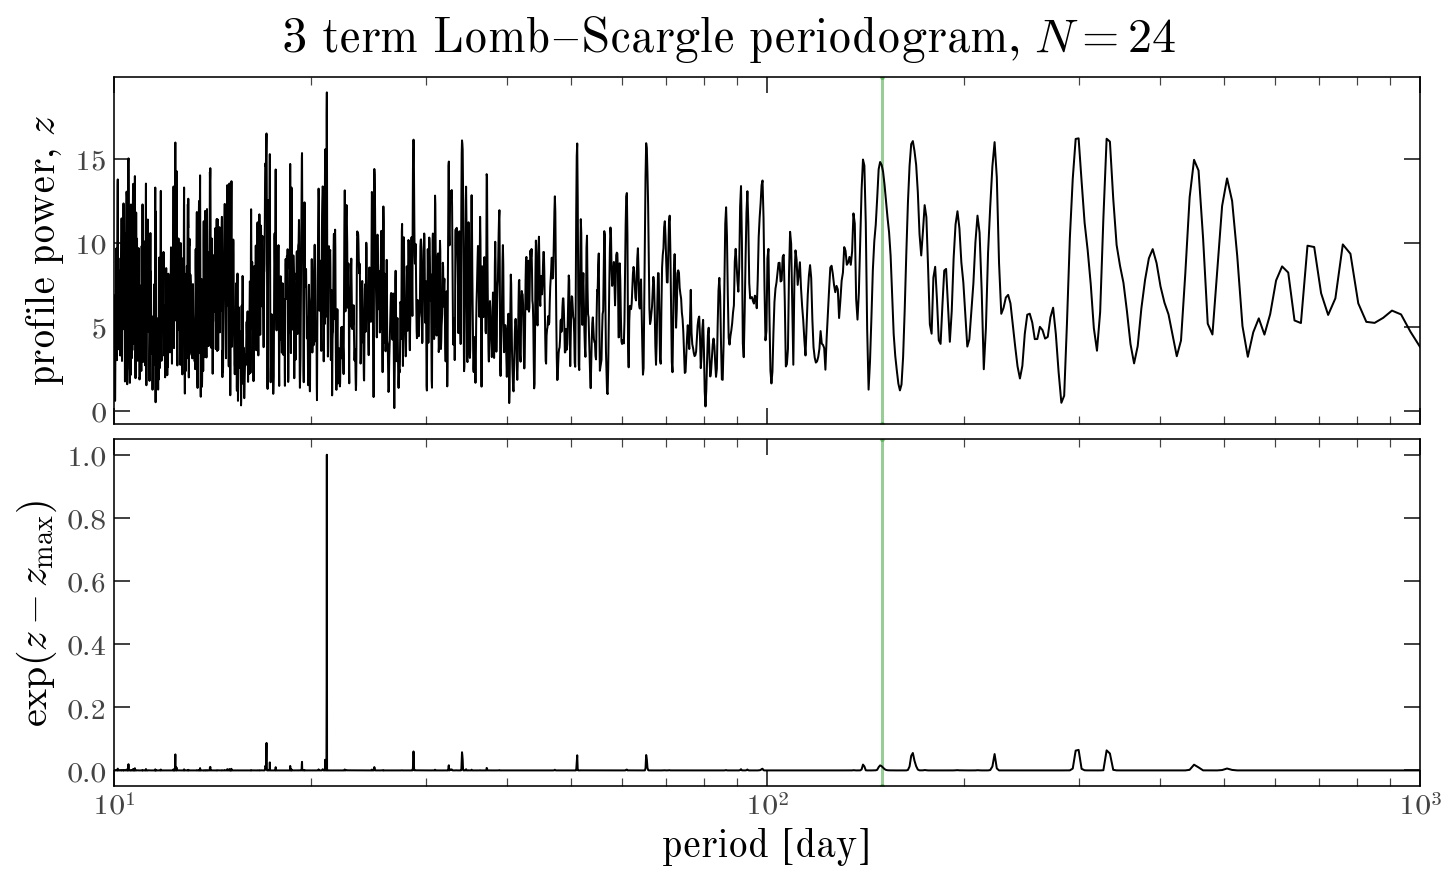

In [11]:
for n_terms, profile_pgram in profile_pgrams_2.items():
    fig, _ = plot_periodogram(profile_pgram)
    _ = fig.suptitle(
        f"{n_terms} term Lomb–Scargle periodogram, $N={data_2.n_times}$", fontsize=24
    )

With fewer epochs, none of these periodograms are conclusive. All of the periodograms show a peak near the true period, but there are many other peaks with similar or higher power. However, as we increase the number of terms, the amplitude of the mode near the true period increases relative to the other modes, even though it is still not the dominant mode. 

Another approach, which we use by default in `harv`, is to marginalize over the amplitudes instead of maximizing. Before we get into the math behind this approach, let's first recap the math behind Lomb–Scargle or profile periodograms, and what we can interpret from the different cases.

## Profile likelihood / generalized Lomb-Scargle periodograms: Mathematical recap

_This recap assumes some familiarity with the math behind Lomb–Scargle and related periodograms — we recommend [this review article](https://arxiv.org/abs/1703.09824) (especially Section 5 and beyond) for a good overview._

We assume we have a dataset of $N$ observations $\{y_n\}$ at times $\{t_n\}$ with uncorrelated uncertainties $\{ \sigma_n \}$, which we can pack into the diagonal of an $N \times N$ noise covariance matrix $C$. We want to compute a periodogram of this data and account for the heteroscedastic uncertainties of the data.
Periodograms are generally computed on a grid of periods or frequencies, so at a given element of the grid, we have a trial frequency $\nu$. 
As defined above, in the case of a Lomb–Scargle periodogram, we want to fit a sinusoidal model to the data at each trial frequency - a model that looks like

$$
y(t) = a \, \cos(2\pi\nu \, t) + b \, \sin(2\pi\nu \, t) + c
$$

where $\boldsymbol{\theta} = (a, b, c)$ are the (linear) parameters of the model. We define $X(\nu)$ to be the design matrix at a trial frequency so that

$$
X(\nu) = \begin{bmatrix}
\cos(2\pi\nu \, t_1) & \sin(2\pi\nu \, t_1) & 1 \\
\cos(2\pi\nu \, t_2) & \sin(2\pi\nu \, t_2) & 1 \\
\vdots & \vdots & \vdots \\
\cos(2\pi\nu \, t_N) & \sin(2\pi\nu \, t_N) & 1
\end{bmatrix} \quad,
$$

so the columns are the cosine and sine terms of each harmonic, plus a column of ones for the constant term. 
With these definitions, the parameters $\boldsymbol{\theta}$ that maximize the likelihood at a given trial frequency are given by the usual least-squares solution

$$
\hat{\theta}(\nu) = \left(X^\top C^{-1} X\right)^{-1} X^\top C^{-1} y \quad .
$$

In the case of the Lomb–Scargle periodogram, the periodogram power is typically defined as the _improvement_ in this model fit over a base model. 
If the base model is a constant-only model, then the base design matrix is just a column of ones, and the base model parameter is just the inverse-variance-weighted mean of the data, $\hat{y} = \sum_i w_i y_i / \sum_i w_i$ where $w_i = 1/\sigma_i^2$.
The periodogram power $z(\nu)$ is then defined as the difference in log-likelihood between the trial model and the base model, evaluated at the optimal parameters,

$$
z(\nu) = \ln \mathcal{N}\!\left(y \mid X\hat{\theta}, C\right)
    - \ln \mathcal{N}\!\left(y \mid \hat{y}, C\right)
$$

which here is identical to the difference in chi-squared between the sinusoid model and the constant model (a base model) evaluated at the optimal parameters

$$
z(\nu) = \tfrac{1}{2}\left[\chi^2_\mathrm{const} - \chi^2_\mathrm{sinusoid}(\nu)\right] \quad .
$$

This periodogram power (with a single sinusoid, $H=1$) is the typical definition of a Lomb–Scargle periodogram (with a floating mean).
Because the sinusoid model contains the base model, $z(\nu) \geq 0$ for all $\nu$.
We could consider other base models, or add more harmonics to the sinusoid (which would add more columns to the design matrix and more linear amplitude parameters, $H > 1$).
We will call this whole family "*profile periodograms*": the amplitudes are profiled (maximized) out at every trial frequency.

### False alarm probabilities and significance of peaks

A periodogram might show structure and peaks (such as in the examples above), but how would we know if those peaks are meaningful?
Because $z(\nu) \geq 0$, we clearly can't threshold on zero.
One way to define a threshold is to ask how often we would see a peak of a given height in an equivalent dataset of pure noise.
This is what a false alarm probability (FAP) helps to answer.

Under the null hypothesis, the data are pure Gaussian noise with the quoted uncertainties distributed around the base model.
The sinusoid model adds $2H$ free parameters to the base model, so at a given frequency, $2 \, z(\nu)$ follows a $\chi^2$ distribution with $2H$ degrees of freedom (the factor of 2 is there because the log-likelihood is $\ln \mathcal{L} = -\tfrac{1}{2}\chi^2 + \mathrm{const.}$, so a difference in log-likelihood is half a difference in $\chi^2$).
The FAP at a given frequency is therefore

$$
p_{\nu}(z) = \Pr\left(\chi^2_{2H} > 2z\right) = Q(H, z) \quad ,
$$

with $Q$ the regularized upper incomplete gamma function.
For the single-harmonic case, $H=1$, this collapses to something familiar:

$$
p_{\nu}(z) = e^{-z} \quad ,
$$

so a power of $z = 7$ at one frequency has a probability of about $e^{-7} \approx 10^{-3}$ of exceeding this power at a given frequency under the base model plus noise.

However, when looking at a periodogram, we look at a whole grid of frequencies (not just one value).
And often you take the maximum of the periodogram to find the best-fit frequency.
So the relevant question is: What is the distribution of $\max_\nu z(\nu)$?
Not the distribution of $z$ at a given frequency.
One way to think of this is "the noise got many chances to make a peak," because we looked at many different values of the frequency, so we should lower or penalize the false alarm appropriately.

That is a conceptually useful way to think about it, but the number of "chances" isn't actually the number of grid points.
This is because the noise is a property of the _data_, not the periodogram, and we have one fixed set of $N$ noisy measurements.
$z(\nu)$ is a deterministic function of the data, so the periodogram isn't a sequence of independent draws at each frequency: it's a smooth curve.
A periodogram peak has a finite width in frequency, $\delta_\nu \sim 1/T$ where $T$ is the baseline of the data, so there is a minimum scale in frequency over which the periodogram can vary.
Therefore, in order for a feature in the periodogram to count as a separate "chance," it has to appear at least $\approx \delta_\nu$ away from other features.

The number of "chances" is therefore actually closer to the number of peak widths that fit inside the range of frequencies we searched, which is the same as the number of distinct peaks the periodogram is able to resolve,

$$
K \approx (\nu_\mathrm{max} - \nu_\mathrm{min}) \, T \quad .
$$

In fact, we have already used this concept under the hood to define the frequency grid above: {py:func}`~harv.periodogram.frequency_grid` puts `samples_per_peak` grid points across each peak width, so a grid of $M$ total points has $K \approx M / \texttt{samples\_per\_peak}$.
If the $K$ peaks are independent, the probability that at least one of them exceeds some power $z$ by chance is

$$
\begin{align}
\mathrm{FAP}(z) &= 1 - \left[1 - p_\nu(z)\right]^{K} \\
&\approx K \, p_\nu(z) \quad ,
\end{align}
$$

where the second line follows from a binomial expansion of the equality in the first line, which is a good approximation when the FAP is small.
However, this is really just a heuristic. 
The effective number of "chances" depends on the observing window, the statistic, and the threshold, and (as we'll see below) it's often better to estimate the FAP using simulations of the data.

For the single harmonic case, $H=1$, with the analytic approximation above, this means that the periodogram power needs to reach a value of $z_\alpha \approx \ln(K / \alpha)$ in order to claim a FAP of $\alpha$ across the whole frequency grid.
This implies that the threshold for a significant peak grows logarithmically with the size of the frequency grid (in units of peak widths).

This result is only strictly true for a single harmonic and for evenly sampled data.
In astronomy, the observing cadence is often not uniform (e.g., nightly observations, or seasonal gaps), which can introduce correlations between the periodogram values at different frequencies, and can also create aliased peaks.
A more general treatment of the FAP for periodograms is discussed in [Baluev (2008)](https://arxiv.org/abs/0711.0330) and [Delisle et al. (2020)](https://arxiv.org/abs/2001.10319).
A more robust way to compute the FAP is to use Monte Carlo simulations.

### Computing the FAP numerically

The analytic counting argument above is a useful way to think about the FAP, but it is not a reliable way to compute it for generic data.
The most direct approach is to instead generate fake datasets that contain no signal, compute their periodograms, and look at the maximum power across many realizations.
This gives us the null distribution of $\max_\nu z(\nu)$ by construction, so it works for any periodogram, any base model, and any time sampling.

We can estimate the false-alarm threshold by simulating data under the base model (i.e. the null hypothesis). 
Here that hypothesis is a constant velocity plus independent Gaussian errors with the quoted uncertainties.
For each realization, we keep the observation times and uncertainties fixed, draw new noise, and record the maximum profile power over the same frequency grid. 
The upper quantiles of those maxima give thresholds for the entire search.
This tests whether the largest observed peak is unusual under the constant model. It does not determine whether that peak identifies the correct orbital period: several aliases of a real signal may exceed the same threshold.
We demonstrate both the analytic and numerical approaches to computing the FAP below, using the same simulated RV data as above.

First, we will compute the analytic estimates of the FAP for a few of the periodograms we already computed above:

In [12]:
def fap_power(fap, K, n_terms=1):
    """The power z whose grid maximum has false alarm probability ``fap``."""
    p_nu = 1.0 - (1.0 - fap) ** (1.0 / K)
    return float(gammainccinv(n_terms, p_nu))

In [13]:
fap_levels = [1e-1, 1e-2, 1e-3]

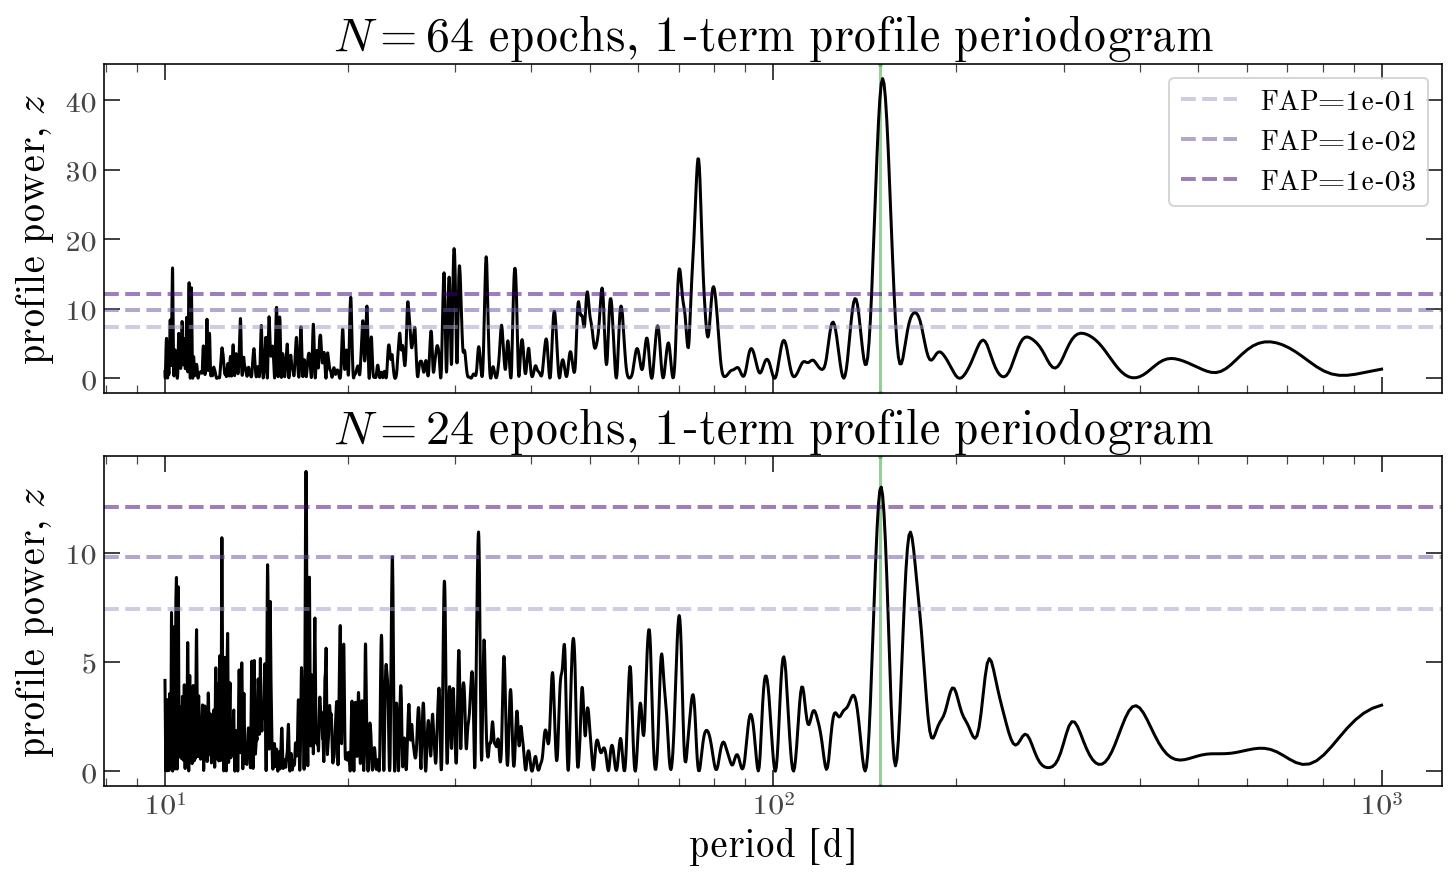

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for pgram, N, ax in zip(
    [profile_pgram_nterms1, profile_pgrams_2[1]],
    [data_1.n_times, data_2.n_times],
    axes,
    strict=True,
):
    K = len(pgram.period) / grid_samples_per_peak

    _ = pgram.plot(ax=ax)
    for tmp, fap in zip(np.linspace(0.5, 1, 3), fap_levels, strict=True):
        ax.axhline(
            fap_power(fap, K),
            color=plt.get_cmap("Purples")(tmp),
            ls="--",
            lw=2.0,
            alpha=0.5,
            label=f"FAP={fap:.0e}",
            marker="",
        )

    ax.set(title=f"$N={N}$ epochs, 1-term profile periodogram")
    ax.set_ylabel("profile power, $z$")

    ax.axvline(
        ustrip("day", truth["period"]),
        color="tab:green",
        ls="-",
        alpha=0.5,
        zorder=-10,
    )

axes[0].set_xlabel("")
axes[0].legend(loc="upper right", fontsize=14)

From the FAP values applied to the 1 term periodograms above, we can see that depending on our FAP threshold, we may consider one or many peaks to be significant. 

As mentioned above, another approach to estimate the FAP is to simulate the base model plus noise. Let's do that for the datasets above and compare to the analytic estimates.

In [15]:
def null_max_power(key, data, grid, n_terms=1, n_trials=4096, chunk_size=32):
    """Maximum profile powers under the quoted Gaussian-noise null."""
    keys = jr.split(key, n_trials)

    def one_trial(key):
        # The profile statistic is invariant to a constant RV offset,
        # so the null's constant velocity can be set to zero here.
        noise = jr.normal(key, shape=data.rv.shape, dtype=jnp.float64)
        simulated = harv.RVData(
            time=data.time,
            rv=data.rv_err * noise,
            rv_err=data.rv_err,
            t_ref=data.t_ref,
        )
        result = hp.periodogram(simulated, grid, prior=False, n_terms=n_terms)
        return result.delta_ln_likelihood.max()

    batched = jax.vmap(one_trial)
    return jnp.concatenate(
        [batched(keys[i : i + chunk_size]) for i in range(0, n_trials, chunk_size)]
    )

Text(0.5, 0, 'period [day]')

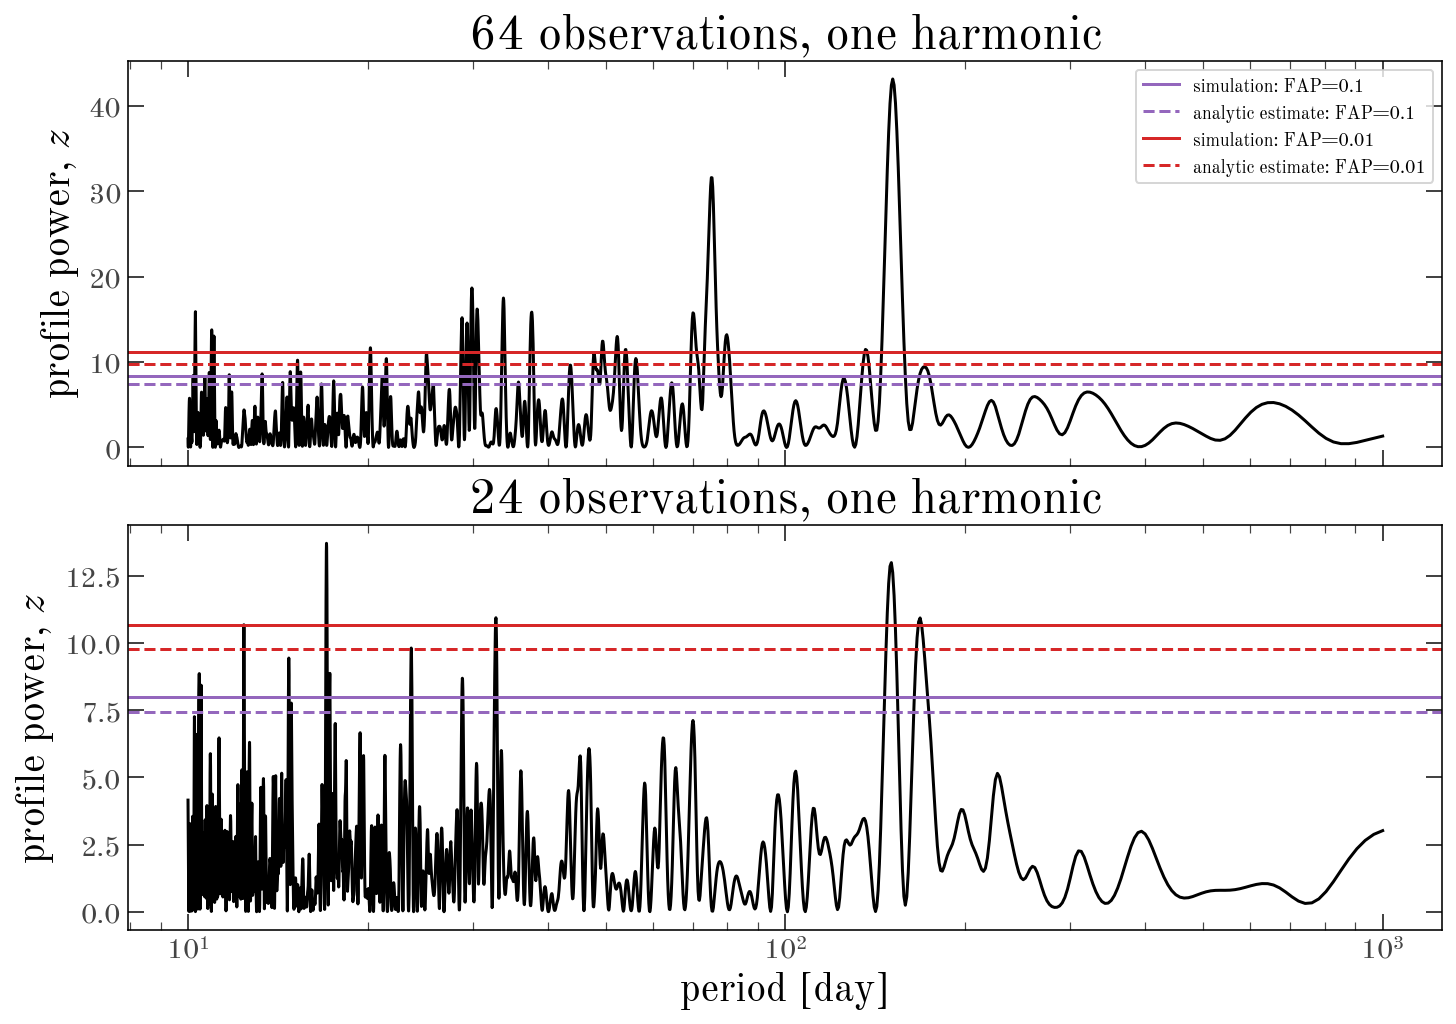

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, layout="constrained")
mc_levels = [0.1, 0.01]
examples = [
    (data_1, profile_pgram_nterms1),
    (data_2, profile_pgrams_2[1]),
]

for key, (data, pgram), ax in zip(jr.split(jr.key(42), 2), examples, axes, strict=True):
    null_peaks = null_max_power(key, data, grid, n_terms=1)

    periods = ustrip("day", pgram.period)
    frequencies = 1.0 / periods
    baseline = jnp.ptp(ustrip("day", data.time))
    effective_trials = jnp.ptp(frequencies) * baseline

    pgram.plot(ax=ax)
    for color, alpha in zip(["tab:purple", "tab:red"], mc_levels, strict=True):
        ax.axhline(
            np.quantile(null_peaks, 1 - alpha),
            color=color,
            ls="-",
            label=f"simulation: FAP={alpha:g}",
            marker="",
        )
        ax.axhline(
            fap_power(alpha, effective_trials),
            color=color,
            ls="--",
            label=f"analytic estimate: FAP={alpha:g}",
            marker="",
        )

    ax.set(
        xscale="log",
        title=f"{data.n_times} observations, one harmonic",
        ylabel=r"profile power, $z$",
    )

axes[0].legend(fontsize=9)
axes[0].set_xlabel("")
axes[-1].set_xlabel("period [day]")

The simulations and the analytic estimate assume the same Gaussian-noise model. 
But they don't have to return the same FAP threshold: the analytic estimate treats the search as a fixed number of independent trials, whereas the simulations retain the actual observing times and correlations between trial frequencies.

The simulated thresholds also have sampling uncertainty. With 4096 realizations, the 1% tail contains about 41 maxima on average. Estimating a 0.001 threshold would require many more simulations, so we restrict to just the 0.1 and 0.01 thresholds.

Note that, for these data, the simulated thresholds are higher than the analytic estimates.
This is expected: the "independent chances" count treats each peak width as one draw, but for a smooth $\chi_2(\nu)$, the number of excursions above a threshold $z$ grows like $\sqrt{z}$, so Baluev's estimate is instead $K\, \sqrt{z} \, e^{-z}$. 
In this case, that raises the threshold about enough to account for the difference.

## The Bayes Factor Periodogram: Marginalizing over the amplitudes

Instead of optimizing for the parameters that maximize the likelihood at each trial period/frequency (i.e. computing a profile periodogram; see the sections above), we can instead put a prior on the amplitudes and integrate them out (i.e. marginalize). 
If the prior is Gaussian, the integral can be done analytically and costs about the same as the least-squares solve:

$$
\begin{align}
Z(\nu) &= \int d\theta \,
    \mathcal{N}(y \mid X \, \theta, C) \, \mathcal{N}(\theta \mid \mu, \Lambda) \\
&= \mathcal{N}(y \mid X \, \mu,\ C + X \Lambda X^\top) \quad .
\end{align}
$$

Here $\mu$ and $\Lambda$ are the mean and covariance of the Gaussian prior on the amplitudes.
We use a zero prior mean in all of the examples below, and we come back to why that is the natural choice for the harmonic amplitudes, but we keep it general for now.

To turn this into a periodogram analogous to a profile periodogram (as defined above), we can compute the marginal likelihood at each trial frequency under the sinusoid model and compare it to the marginal likelihood of a constant model (or other base model). The periodogram power is then $\Delta(\nu) = \ln Z(\nu) - \ln Z_\mathrm{base}$. 
In this version of a periodogram, $\Delta$ (the periodogram power) is a log-Bayes factor comparing a "constant + orbit harmonics" model versus "constant" model at each trial frequency, rather than a profile log-likelihood ratio. 

At a fixed trial frequency, $\exp(\Delta)$ is the Bayes factor for the Fourier model against the base model. 
Positive values of $\Delta$ mean that the data favor the Fourier model, and negative values favor the base model. 
This interpretation requires proper priors, and including the same prior on shared  parameters (i.e. parameters that appear in both the base and Fourier model, like the zero-point).

The nice advantage here is that we don't need to separately compute a false-alarm probability to interpret this ratio!
This answers a different question though, because a Bayes factor is fundamentally a model comparison statistic. 
However, posterior model _odds_ are the Bayes factor multiplied by prior model odds, so $\Delta>0$ alone is not a universal detection criterion.
For example, in a search for companions over many stars where you expect ~1% to host the companions you're looking for, the prior odds are 1:100; so you would want $\Delta \gtrsim \ln 100 \approx 4.6$ before the posterior odds favor a companion.

One last comment on interpreting these marginal or  Bayes factor periodograms is that they are also conditioned on period. 
If we want to compute the evidence for a signal with an unknown period/frequency, we would need to integrate over a normalized frequency prior as well.
With the periodogram, we can only compare the evidence for a signal at a given trial frequency to the base model.

Another outcome of the marginalization is that the Bayes factor power naturally contains an Occam penalty, which acts as a penalty for the number of free parameters in the model. 
So adding a harmonic only increases $\Delta$ if it improves the fit by more than that factor.
This is not what happens in the profile case: There, adding more parameters (e.g., more harmonics) will _never_ decrease the periodogram power (even if it is just latching onto noise).

Let's define that the Occam term more concretely.
If $\Lambda$ is the prior covariance of the amplitudes $\theta$ (often diagonal), and $\mu$ is the prior mean, we define

$$
F(\nu) = X^\top C^{-1} X \quad , \qquad
r(\nu) = y - X \, \mu \quad , \qquad
b(\nu) = X^\top C^{-1} r \quad ,
$$

where $F$ is the Fisher information matrix of the amplitudes, $r$ is the residual of the data from the prediction of the prior mean, and $b$ is that residual projected onto the model columns.

With these definitions, the (log) marginal likelihood above expands to

$$
\ln Z(\nu) = -\tfrac{1}{2} r^\top C^{-1} r
    + \tfrac{1}{2} b^\top \left(F + \Lambda^{-1}\right)^{-1} b
    - \underbrace{\tfrac{1}{2} \ln \det\!\left(I + \Lambda F\right)}_{O(\nu)}
    + \mathrm{const.} \quad ,
$$

where the constant depends only on the data and cancels in $\Delta$. 
Setting $\mu = 0$ gives $r = y$, which is the centered case.
The first two terms measure how well the model fits, and the third is the "Occam factor" or Occam term,

$$
O(\nu) = \tfrac{1}{2} \ln \det\!\left(I + \Lambda \, X^\top C^{-1} X\right) \quad .
$$

$O(\nu)$ compares the width of the prior on each amplitude to how tightly the data constrain that amplitude. 
Note that the Occam term does not depend on the measured velocities (data $y$) or the prior mean: it depends only on the prior covariance, the design matrix, and the noise.
For a single amplitude with prior width $\sigma$ that the data constrain with Fisher information $\lambda$, it contributes $\tfrac{1}{2}\ln(1 + \sigma^2 \, \lambda)$, which is close to zero when the prior is narrower than the data can resolve and grows like $\ln \sigma$ if the data constrain the amplitude well. 
Summed over columns, a well-constrained model gets roughly an additional factor of $\ln\sigma$ per amplitude column, so $\Delta \approx z - \Delta O$ where $\Delta O$ is the difference in Occam term between the trial and base models. 
This is effectively a penalty for adding more parameters to the model.
By the way: this is very related to the "Bayesian Information Criterion" (BIC) often used for model selection, which contains an approximation to the Occam term in the limit of large data (where the data is large enough that the prior scales don't matter, which is why the BIC does not require defining a prior).

With a broad, period-independent prior, 

$$
\Delta(\nu) \approx z(\nu) − N_{\mathrm{amp}} \, \ln \sigma − \frac{1}{2} \ln \mathrm{det} F(\nu) + \mathrm{const.} \quad . 
$$

For well-sampled data, $\ln \mathrm{det} F$ barely varies with $\nu$, so the marginal and profile periodograms differ by a near-constant offset.
What we've gained, however, is (1) a periodogram power that is interpretable directly as a log-Bayes factor, and (2) a way to naturally penalize overfitting when adding more complexity to the model (from the Occam term).

So how do we choose the prior on the linear amplitudes?
The simplest form of the prior would have period-independent widths `sigma_amp` on the harmonic amplitudes and `sigma_v0` on the systemic velocity, both with zero mean.
For the harmonic amplitudes, a zero mean is generally the best choice:
A harmonic contributes $a \, \cos(2\pi \, k \, \nu \, t) + b \, \sin(2\pi \, k \, \nu \, t)$ to the model, so shifting the reference epoch changes $t$ by a constant phase, which rotates the pair $(a, b)$.
A zero-mean prior with equal widths on the amplitudes is then invariant under a rotation, so the periodogram then doesn't depend on reference epoch (as we probably want!).

But the intuition is different for the base model parameters. 
We might know something about the distribution of expected systemic velocities (in the RV case), or the astrometric solution (for Gaia astrometry), so we might want to put a prior on the base model parameters that is not zero-mean.
Note that a non-zero mean value does not cancel out of the Bayes factor periodogram power $\Delta$, but it can actually improve the meaningfulness of the Bayes factor.

Let's compare the marginal and profile periodograms on the same data we used above.

Text(0.5, 1.0, '$N=24$')

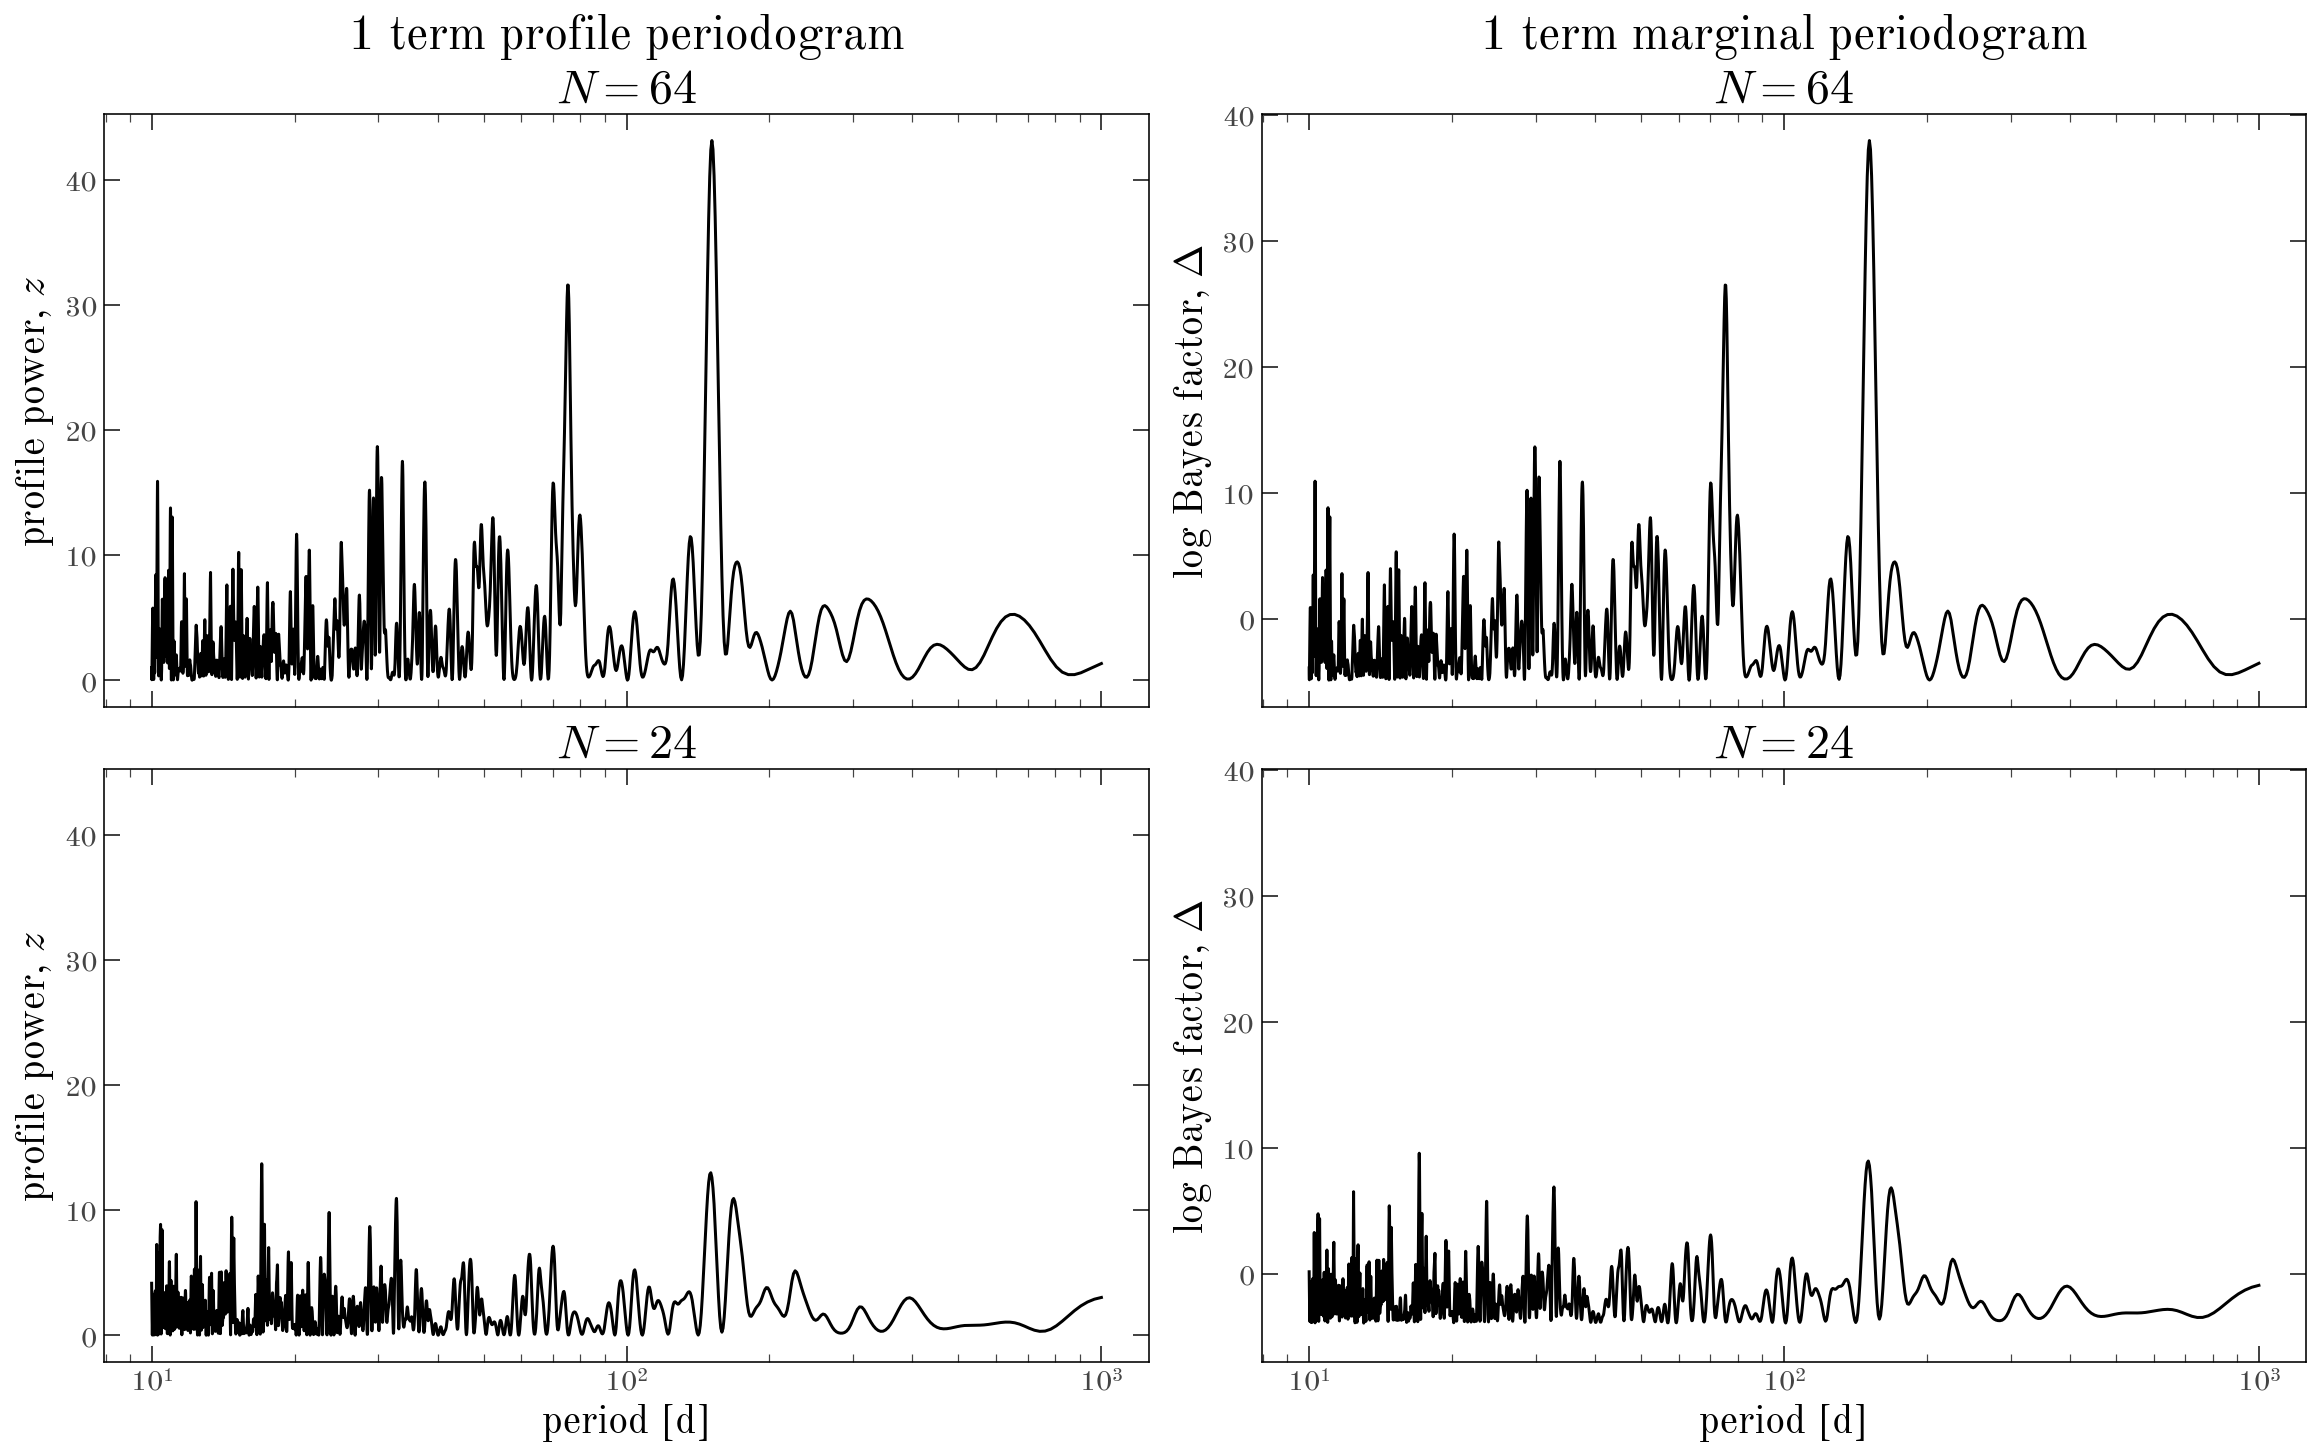

In [17]:
fourier_prior = hm.FourierRV(n_terms=1).default_prior(
    period_min=P_min,
    period_max=P_max,
    sigma_amp=Q(1.0, "km/s"),
    sigma_v0=Q(100.0, "km/s"),
)

fig, axes = plt.subplots(
    2, 2, figsize=(16, 10), sharex=True, sharey="col", layout="constrained"
)

for pgram, ax in zip(
    [profile_pgram_nterms1, profile_pgrams_2[1]], axes[:, 0], strict=True
):
    pgram.plot(ax=ax)

for data, ax in zip([data_1, data_2], axes[:, 1], strict=True):
    marginal_const_amp = hp.periodogram(data, grid, prior=fourier_prior, n_terms=1)
    marginal_const_amp.plot(ax=ax)

for ax in axes[0]:
    ax.set_xlabel("")
for ax in axes[:, 0]:
    ax.set_ylabel("profile power, $z$")
for ax in axes[:, 1]:
    ax.set_ylabel(r"log Bayes factor, $\Delta$")

axes[0, 0].set_title(f"1 term profile periodogram\n$N={data_1.n_times}$", fontsize=24)
axes[1, 0].set_title(f"$N={data_2.n_times}$", fontsize=24)

axes[0, 1].set_title(f"1 term marginal periodogram\n$N={data_1.n_times}$", fontsize=24)
axes[1, 1].set_title(f"$N={data_2.n_times}$", fontsize=24)

Indeed, for both of our datasets, the marginal and profile periodograms are very similar (left vs. right columns in the above figure).

Let's now explore how the prior width affects the marginal periodogram.

Text(0.5, 0, 'period [day]')

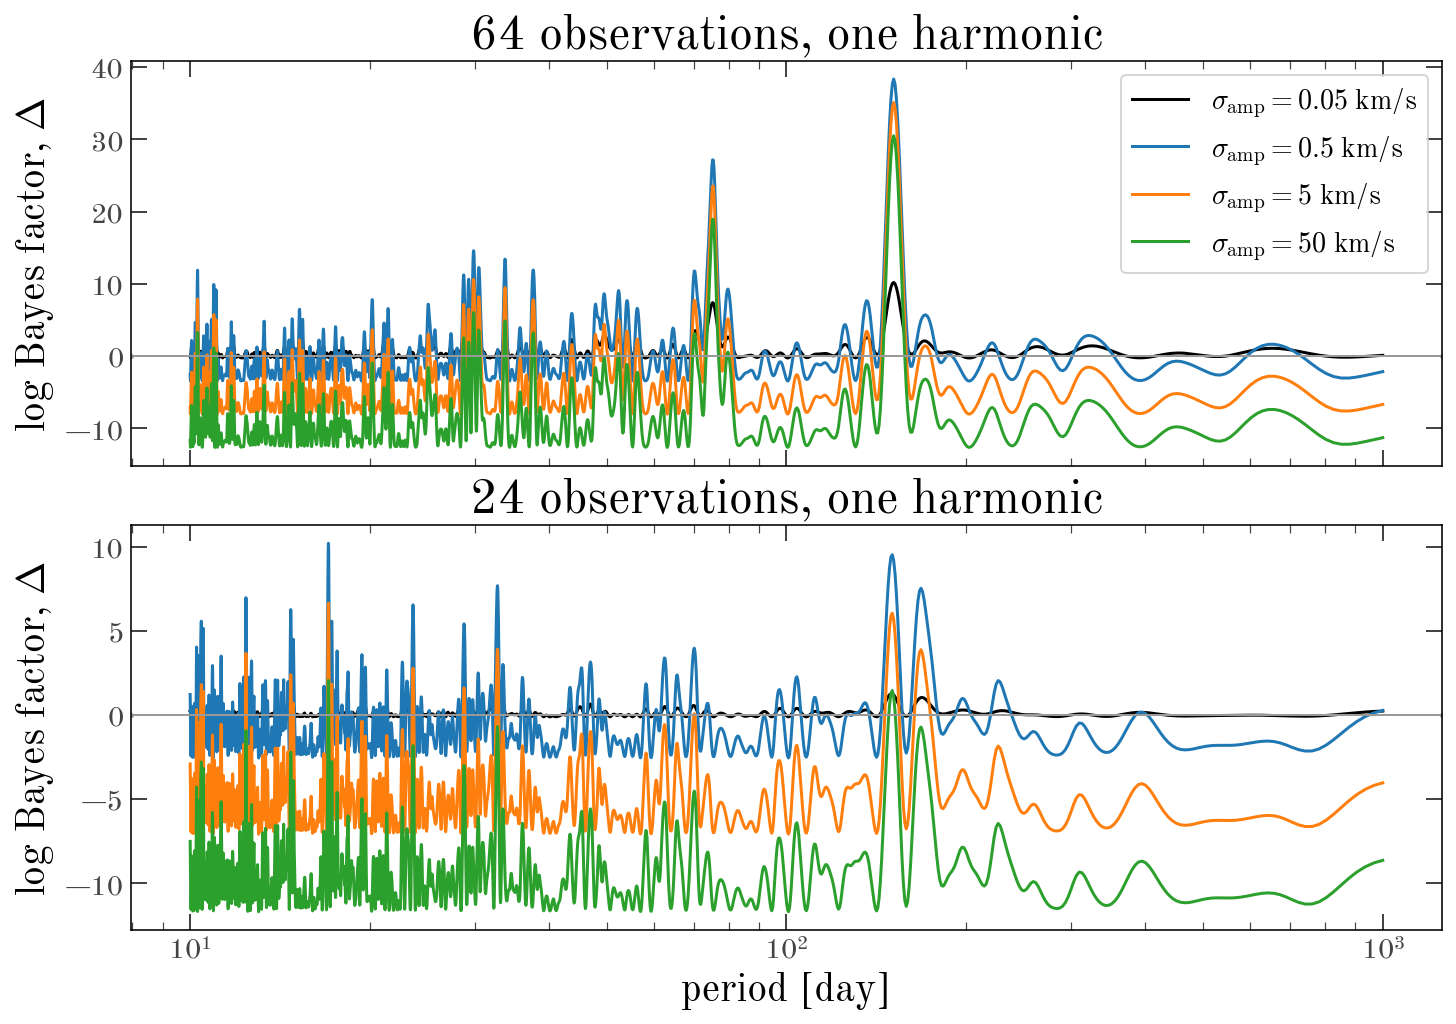

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, layout="constrained")

for data, ax in zip([data_1, data_2], axes, strict=True):
    for width in [0.05, 0.5, 5.0, 50.0]:
        prior = hm.FourierRV(n_terms=1).default_prior(
            period_min=P_min,
            period_max=P_max,
            sigma_amp=Q(width, "km/s"),
            sigma_v0=Q(100.0, "km/s"),
        )
        result = hp.periodogram(data, grid, prior=prior, n_terms=1)
        ax.plot(
            ustrip("day", result.period),
            result.delta_ln_likelihood,
            label=rf"$\sigma_{{\rm amp}}={width:g}$ km/s",
            marker="",
        )

    ax.axhline(0, color="0.6", lw=1)
    ax.set(
        xscale="log",
        ylabel=r"log Bayes factor, $\Delta$",
        title=f"{data.n_times} observations, one harmonic",
    )

axes[0].legend(fontsize=14)
axes[-1].set_xlabel("period [day]")

Varying the prior width on the harmonic amplitudes changes the Occam term, which, for these datasets, mainly changes the overall offset of the periodogram power. 
However, if you look closely, you'll see that the relative heights of the peaks also change slightly --- especially for the smallest amplitude scale $\sigma = 0.05$ (black) --- and this is expected.

When $\sigma_{\mathrm{amp}}$ is much wider than the amplitudes the data can support, the Occam term is $\approx N_{\mathrm{amp}} \, \ln \sigma_{\mathrm{amp}}$ --- i.e. the same at every period --- so the whole periodogram shifts down for each factor of 10 in $\sigma_{\mathrm{amp}}$ (compare the 0.5, 5, and 50 km/s curves); the peak ranking doesn't change. 
When $\sigma_{\mathrm{amp}}$ is narrower than the data can resolve, shrinkage pulls the fit toward the base model everywhere and $\Delta \rightarrow 0$ --- the 0.05 km/s curve is nearly flat. 
In between, a peak whose fitted amplitude is larger than $\sigma_{\mathrm{amp}}$ is shrunk by $\approx \frac{1}{2} \frac{|\hat{\theta}|^2}{\sigma_{\mathrm{amp}}^2}$.
This penalty becomes more important when we allow the prior to be a function of period as we'll see below.

If the prior scale is too large, a smaller amplitude signal is penalized more than a larger amplitude signal, which shifts the whole periodogram toward smaller values of $\Delta$.
If the prior scale is too small, the periodogram will tend to "flatten" because the prior is too restrictive to allow the data to fit well, so it begins to prefer the base model over the sinusoid model everywhere.

### Multiple harmonics in the marginalized periodogram

We now return to the idea of including multiple harmonics, but now in the marginalized periodogram. 
How does the Bayes factor periodogram change as we add more harmonics to the model?
Here we keep the priors on shared coefficients unchanged as we add more harmonics.

For the profile statistic, adding a harmonic cannot decrease the power at any frequency. 
The marginal statistic does not have to behave this way because of the Occam term, which can penalize the addition of a harmonic if it does not improve the fit enough to overcome the penalty.

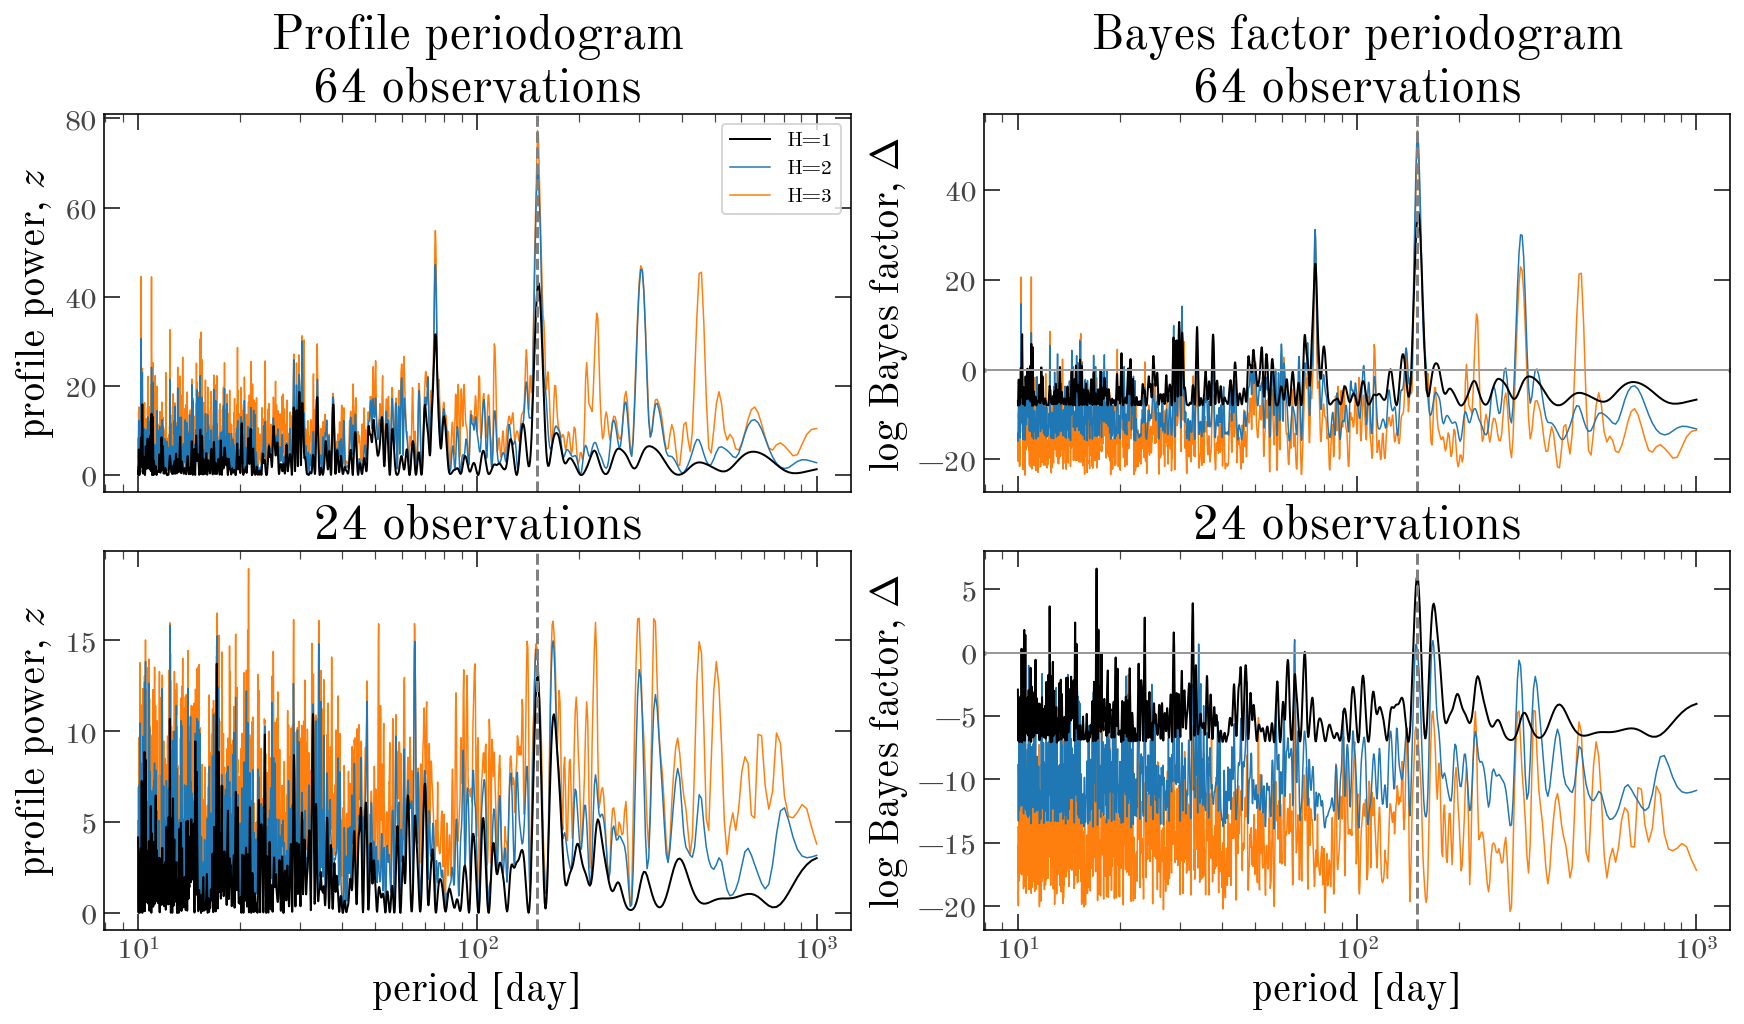

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, layout="constrained")

for data, row in zip([data_1, data_2], axes, strict=True):
    for H, lw in zip([1, 2, 3], [1.0, 0.75, 0.75], strict=True):
        prior_h = hm.FourierRV(n_terms=H).default_prior(
            period_min=P_min,
            period_max=P_max,
            sigma_amp=Q(5.0, "km/s"),
            sigma_v0=Q(100.0, "km/s"),
        )
        profile = hp.periodogram(data, grid, prior=False, n_terms=H)
        marginal = hp.periodogram(data, grid, prior=prior_h, n_terms=H)

        for ax, result in zip(row, [profile, marginal], strict=True):
            ax.plot(
                ustrip("day", result.period),
                result.delta_ln_likelihood,
                label=f"H={H}",
                marker="",
                lw=lw,
                zorder=3 - H,
            )

    for ax in row:
        ax.set_xscale("log")
        ax.axvline(
            float(ustrip("day", rv_params["period"])), color="0.5", ls="--", marker=""
        )
        ax.set_title(f"{data.n_times} observations")

    row[0].set_ylabel(r"profile power, $z$")
    row[1].set_ylabel(r"log Bayes factor, $\Delta$")
    row[1].axhline(0, color="0.6", lw=1)


axes[0, 0].set_title(f"Profile periodogram\n{axes[0, 0].get_title()}", fontsize=24)
axes[0, 1].set_title(f"Bayes factor periodogram\n{axes[0, 1].get_title()}", fontsize=24)

axes[0, 0].legend()
for ax in axes[-1]:
    ax.set_xlabel("period [day]")

Indeed, we see opposite behavior in the profile periodogram (left column) and the marginal periodogram (right column) as we add more harmonics to the model.
For the profile periodogram, as we add harmonics, all peaks in the periodogram increase in power.
For the marginal periodogram, as we add harmonics, most of the peaks decrease in power due to the Occam term.

### Period-dependent amplitude priors

So far we've used an amplitude prior that is constant with period. 
In this regime, the marginal periodogram is essentially the profile periodogram plus a constant -- the Occam factor, which is a function of the prior widths and the data.
With a marginal periodogram, however, we could also choose a prior that is a function of the period.
Why would we want to do this?

In the setup presumed for `harv`, we are searching for orbits.
Orbits obey Kepler's third law, so for a constant mass system, the amplitude (in radial velocity amplitude or semi-major axis) should scale with period. 
For example, for astrometry at fixed masses, $a \propto P^{2/3}$. 
For radial velocity semi-amplitude, $K \propto P^{-1/3}$.
`harv` allows the amplitude prior to be a function of period, so we can encode this knowledge into the periodogram. 

Since we're working with radial velocity data in our examples so far, we will set up an amplitude prior that scales with $P^{-1/3}$. 
More specifically, we set the prior scale on the amplitides to be $\sigma(P) = \sigma_{K,0} \times (P / P_0)^{-1/3}$. 
We can enable this in `harv` by specifying $\sigma_{K,0}$ (`sigma_K0`) and $P_0$ (`P0`) in the prior:

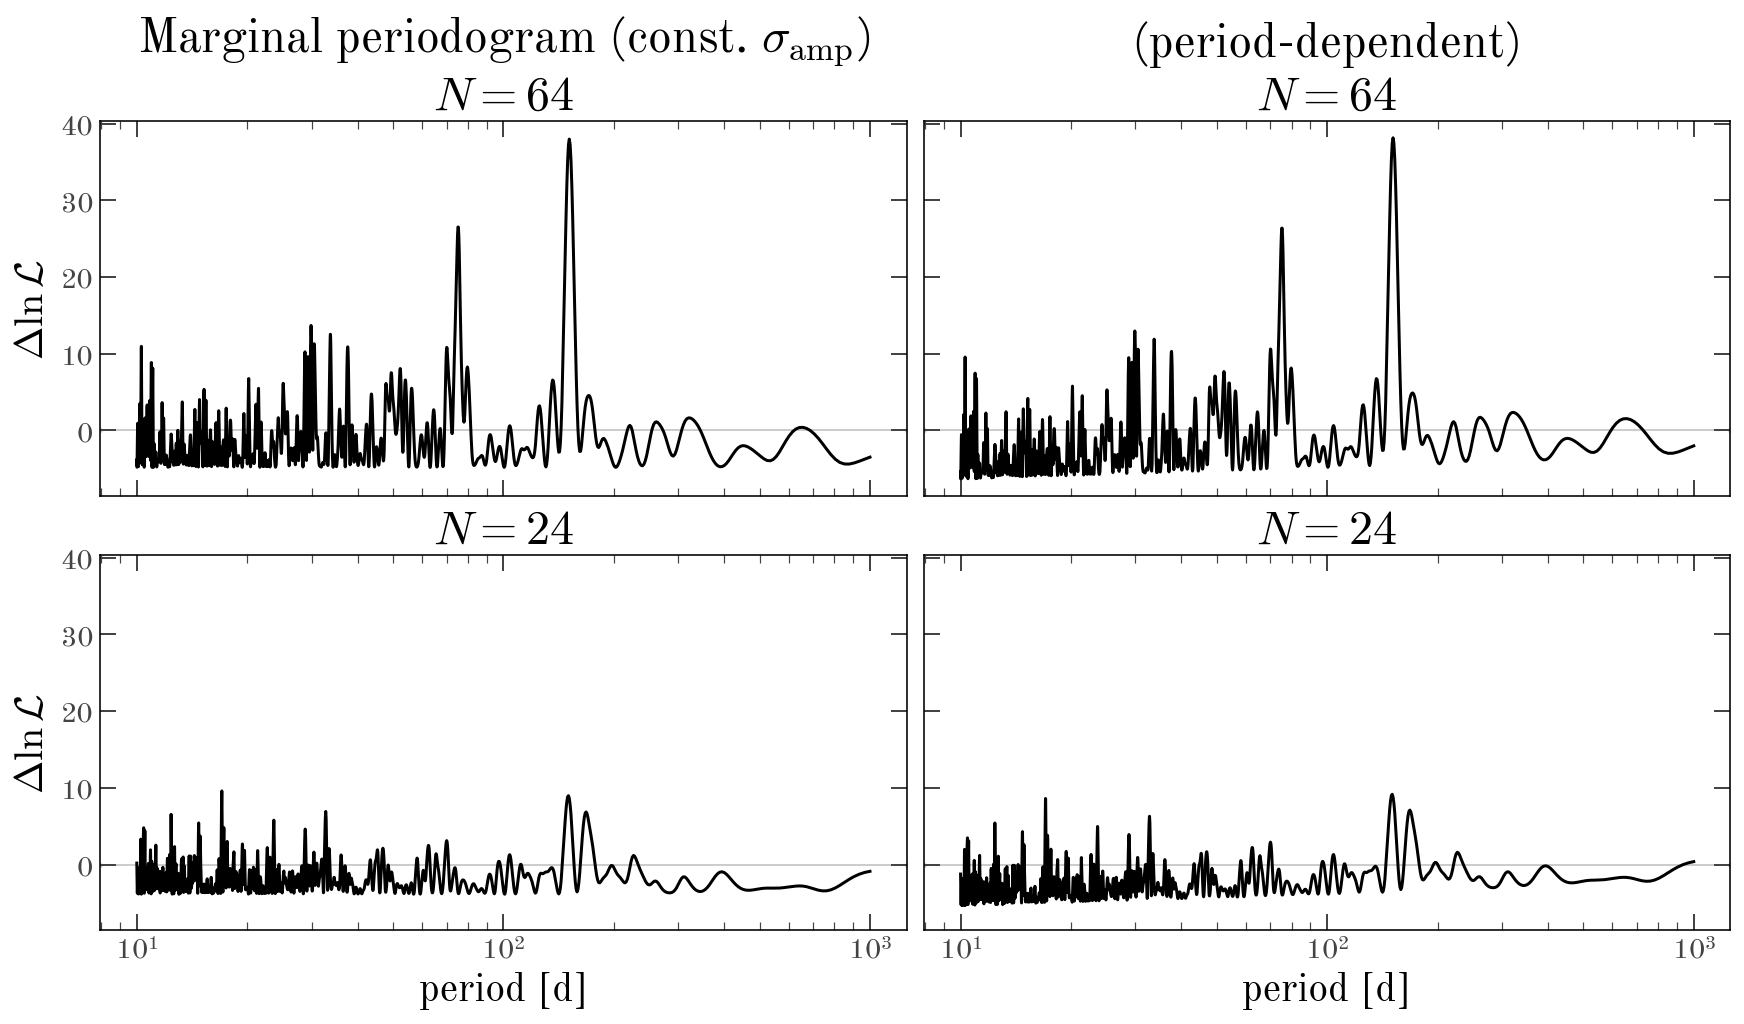

In [20]:
fourier_prior_P_dep = hm.FourierRV(n_terms=1).default_prior(
    period_min=P_min,
    period_max=P_max,
    sigma_K0=Q(1, "km/s"),
    P0=Q(100.0, "day"),
    sigma_v0=Q(100.0, "km/s"),
)

fig, axes = plt.subplots(
    2, 2, figsize=(12, 7), sharex=True, sharey=True, layout="constrained"
)

for data, ax in zip([data_1, data_2], axes[:, 0], strict=True):
    marginal_const_amp = hp.periodogram(data, grid, prior=fourier_prior, n_terms=1)
    marginal_const_amp.plot(ax=ax)

for data, ax in zip([data_1, data_2], axes[:, 1], strict=True):
    marginal_P_dep = hp.periodogram(data, grid, prior=fourier_prior_P_dep, n_terms=1)
    marginal_P_dep.plot(ax=ax)

for ax in axes[0]:
    ax.set_xlabel("")
for ax in axes[:, 1]:
    ax.set_ylabel("")

axes[0, 0].set_title(
    r"Marginal periodogram (const. $\sigma_{\mathrm{amp}}$)"
    f"\n$N={data_1.n_times}$",
    fontsize=24,
)
axes[1, 0].set_title(f"$N={data_2.n_times}$", fontsize=24)

axes[0, 1].set_title(f"(period-dependent)\n$N={data_1.n_times}$", fontsize=24)
axes[1, 1].set_title(f"$N={data_2.n_times}$", fontsize=24)

for ax in axes.flat:
    ax.axhline(0.0, color="#cccccc", lw=1, zorder=-10)

For these datasets, the period-dependent prior tilts the whole periodogram to prefer longer periods, which is consistent with the expected scaling of the radial velocity amplitude with period.

### How the amplitude prior scale enters

The prior enters $\ln Z$ through the fit term $\tfrac{1}{2}\, b^\top (F + \Lambda^{-1})^{-1} b$ and the Occam term $O(\nu)$. 
At a given trial period, what matters is how the prior width $\sigma(P)$ compares to two scales: the uncertainty on each harmonic amplitude from the data alone, $1/\sqrt{\lambda} \approx \sigma_n \sqrt{2/N}$, and the fitted amplitude at that period, $|\hat{\theta}(P)|$. There are three regimes (where recall that $\lambda$ is the Fisher information of the amplitudes, so $1/\sqrt{\lambda}$ is the uncertainty on the amplitude from the data alone):

- Where it is narrow, $\sigma(P) \ll 1/\sqrt{\lambda}$, the fit prefers the base model and $O(\nu) \to 0$, so $\Delta \to 0$. Where this holds across the grid, the periodogram is flat even though the prior is not (the $\sigma_{\rm amp} = 0.05$ km/s curve above is close to this limit; plx-G19 in the astrometry section below is definitely in this limit).
- Where it is broad, $\sigma(P) \gg 1/\sqrt{\lambda}$ and $\gg |\hat{\theta}(P)|$, shrinkage is negligible and $O(\nu) \approx N_{\rm amp} \ln \sigma(P) + \mathrm{const.}$. Scaling $\sigma_{K,0}$ by $s$ shifts $\Delta$ by $-N_{\rm amp} \ln s$ at every period. Relative to a constant prior of the same width at $P_0$, the prior $\sigma(P) = \sigma_{K,0}\,(P/P_0)^\beta$ adds $-N_{\rm amp}\,\beta\,\ln(P/P_0)$ — for one RV harmonic, $+\tfrac{2}{3}\ln(P/P_0)$, about 3 log units across our period grid. This tilt is set by $\beta$ alone.
- Where it is intermediate, $1/\sqrt{\lambda} \ll \sigma(P) \lesssim |\hat{\theta}(P)|$, the peak is shrunk by $\approx \tfrac{1}{2}\,|\hat{\theta}(P)|^2 / \sigma(P)^2$, i.e. the prior evaluated at the fitted amplitude. This is where the prior can help: a peak whose amplitude is implausible (given the types of companions being searched for) is suppressed, and the peaks can be reordered.

So $\sigma_{K,0}$ sets the overall level of $\Delta$ (and so how many trial periods clear $\Delta = 0$) and which peaks get shrunk. 
A prior much wider than any signal you would believe just pushes $\Delta$ down everywhere, so the usual "use a wide prior to be uninformative" advice does not apply here. 
Set $\sigma_{K,0}$ to the scale of the companions you are searching for (exoplanet, stellar, compact object), and put $P_0$ anywhere convenient.

### Profile vs. Bayes factor periodograms

The profile and Bayes factor / marginal periodograms really answer different questions, and we should therefore threshold and use them differently.
Setting a threshold with a false-alarm probability asks how often the base model would produce a maximum profile power at least as large as the threshold. 
A fixed-period Bayes factor compares the sinusoid and base models after averaging over the amplitude priors and is really a statement about the relative evidence for the two models at a given period. 
Neither quantity, by itself, gives the probability that the highest peak is the correct orbital period.

For a sinusoid model with an unknown period, the full Bayes factor against the base model is

$$
B_{\mathrm{sinusoid,base}}
=\int \exp[\Delta(P)]\,p(P\mid M_{\mathrm{sinusoid}})\,dP,
$$

using a normalized period prior and the same base evidence throughout. 
This accounts for peak widths as well as heights in the periodogram.

The integral is over the same grid we already computed, so it's straightforward to compute. 
With a log-uniform period prior, $p(P \mid M_{\rm sinusoid}) \, dP = d\ln P / \ln(P_{\rm max}/P_{\rm min})$, the integral becomes an average of $\exp[\Delta(P)]$ over $\ln P$. 
We evaluate it in log space to avoid overflow, since $\Delta$ can be large at the peak:


In [ ]:
from jax.scipy.special import logsumexp


def total_log_bayes_factor(pgram):
    """Ln B for a sinusoid at unknown period, under a log-uniform period prior."""
    ln_P = jnp.log(ustrip("day", pgram.period))
    order = jnp.argsort(ln_P)
    ln_P = np.asarray(ln_P[order])
    delta = pgram.delta_ln_likelihood[order]

    # Trapezoid weights for the integral over ln P:
    d_ln_P = np.diff(ln_P)
    weights = np.concatenate(
        [[d_ln_P[0] / 2], (d_ln_P[:-1] + d_ln_P[1:]) / 2, [d_ln_P[-1] / 2]]
    )

    return logsumexp(delta, b=weights) - np.log(ln_P[-1] - ln_P[0])


for data in [data_1, data_2]:
    pgram = hp.periodogram(data, grid, prior=fourier_prior, n_terms=1)
    ln_B = total_log_bayes_factor(pgram)
    print(
        f"N={data.n_times:3d}:  max Delta = {pgram.delta_ln_likelihood.max():6.2f}, "
        f"ln B = {ln_B:6.2f}"
    )

N= 64:  max Delta =  37.97, ln B =  31.94
N= 24:  max Delta =   9.59, ln B =   3.86


$\ln B$ is smaller than the peak value of $\Delta$, and the difference is the period search's own Occam penalty: a tall but narrow peak is diluted by the width of the period. 
The ratio of the peak width to the searched range plays the same role here that $K$ played in the false-alarm calculation, but it appears automatically rather than as a separate correction.

This is the number to combine with prior odds. 
If you expect a fraction $f$ of the stars in a survey to host the companions you are searching for, the posterior odds are $B \, f / (1 - f)$, so for $f \sim 0.01$ you would want $\ln B \gtrsim \ln 100 \approx 4.6$ before the data favor a companion at all. 
Note that $B$ still depends on the amplitude prior: it is the evidence for a signal of the amplitude scale you specified, which is why the Gaia examples below can be flat rather than merely inconclusive.

Some combination of cuts on FAP from a profile periodogram, on the Bayes factor periodogram, and on the total Bayes factor may be the safest and most effective way to identify a candidate signal in a large search.

## Gaia astrometry

Our examples so far have focused on radial velocity data, but the periodogram functionality in `harv` also supports other kinds of data, like (Gaia) astrometry. To use it with astrometric data, we have to change the data container class we are using for the data and change the model construction before passing into {py:func}`harv.periodogram.periodogram`. We demonstrate below with real Gaia astrometry data from the [Gaia DR4 prerelease](https://www.cosmos.esa.int/web/gaia/dr4-prerelease).

Gaia epoch astrometry is a good second demonstration of the periodogram functionality because it is quite different from radial velocity data. The Gaia astrometric data is a 1D projection of the source's 2D sky position onto the scan direction, so the model fundamentally has two dimensions of motion, which means the periodogram model has more linear parameters than the radial velocity case. The signal in the vast majority of Gaia sources is dominated by the linear parameters (position, proper motion, parallax), so the periodogram of any Keplerian signal has to be sensitive to small perturbations on top of that linear motion.

We'll look at three systems, and in every case we will assume we are searching for an exoplanet-mass companion (this matters because it sets our prior expectations for the scale of the expected signal).

- `Gaia-4` (Gaia DR4 1457486023639239296) hosts a known giant planet on a ~571 day   
  orbit, and is bright enough that the orbit is detected easily.
- `plx-G9` (Gaia DR4 4181040337841125632) has no known companion, but has comparably 
   precise astrometry.
- `plx-G19` (Gaia DR4 3926186255616949504) also has no known companion, but is much 
  fainter, so the per-transit astrometric uncertainties are about twenty times larger.

Let's load all three:

In [22]:
def load_gaia_prerelease(name):
    """Load one Gaia DR4 prerelease epoch-astrometry table.

    Returns the ``GaiaAstrometryData``, the catalog parallax, and the known
    orbital period (``nan`` for the systems with no known companion).
    """
    tbl = QTable.read(f"../data/gaia-dr4-prerelease/{name}.ecsv")
    cols = {
        col: (Q.from_(tbl[col]) if tbl[col].unit is not None else jnp.array(tbl[col]))
        for col in tbl.colnames
    }
    data = hd.GaiaAstrometryData(
        time=cols["relative_time"],
        al_position=cols["pos_al"],
        al_position_err=cols["pos_al_err"],
        scan_angle=cols["scan_angle"],
        parallax_factor=cols["parallax_factor"],
        t_ref=Q(0.0, "day"),
    )
    return data, Q(tbl.meta["parallax_mas"], "mas"), tbl.meta["period_day"]


gaia_names = ["Gaia-4", "plx-G9", "plx-G19"]
gaia_data = {name: load_gaia_prerelease(name) for name in gaia_names}

Let's visualize the three datasets:

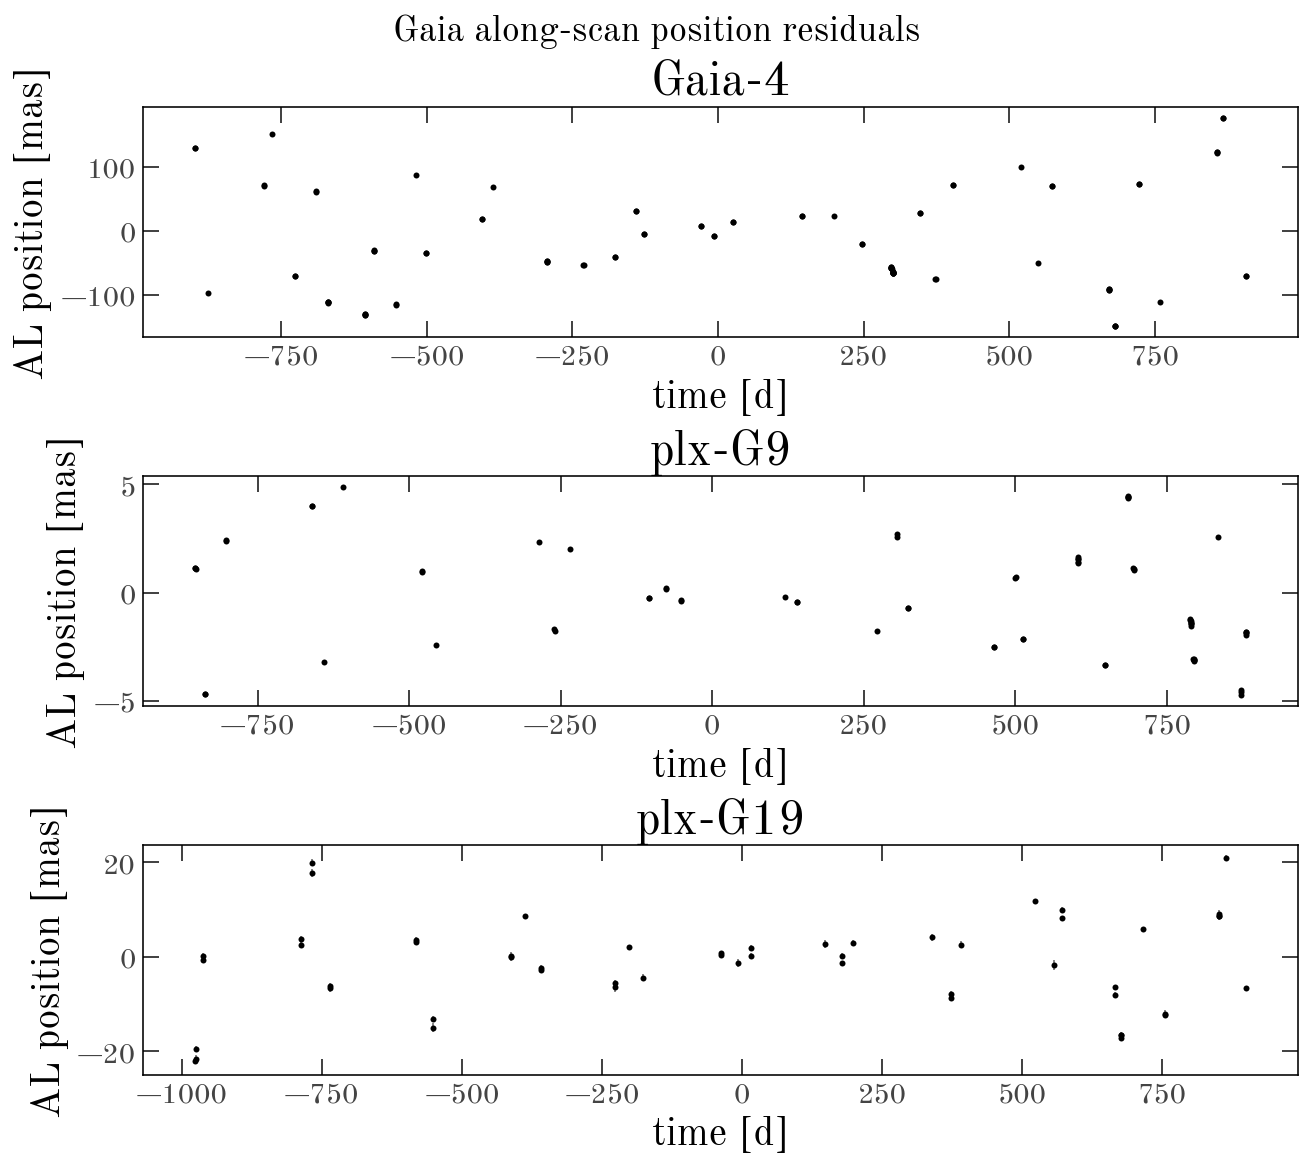

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), layout="constrained")
for ax, (name, (data, _, _)) in zip(axes, gaia_data.items(), strict=True):
    data.plot(ax=ax)
    ax.set_title(name)
_ = fig.suptitle("Gaia along-scan position residuals", fontsize=18)

The three datasets look similar in structure and the signal is mostly dominated by the parallax and linear motion of each source. But note the very different vertical scales in the three panels.

Now we have to choose the amplitude prior. Since we are searching for exoplanet-mass companions in all three systems, we can set the period-dependent prior scale from that assumption. For a companion of mass $m_2$ orbiting a star of mass $m_1$, the star's own orbit about the barycenter has semi-major axis $a_1 \approx a_\mathrm{rel} \, m_2 / m_1$. At $P_0 = 1$ year around a solar-mass star, $a_\mathrm{rel} \approx 1\,\mathrm{AU}$, so a $10\,M_\mathrm{Jup}$ companion gives $a_1 \approx 1\,\mathrm{AU} \times 10\,M_\mathrm{Jup} / M_\odot \approx 0.01\,\mathrm{AU}$. We adopt this value as the prior scale for `sigma_a0`.

One complication here that is specific to astrometry is that `sigma_a0` is a physical length, so turning it into an _angular_ prior width requires a parallax. The periodogram marginalizes over the parallax rather than sampling it, so there is no parallax value for the prior to read. In `harv`, we currently therefore have to supply a parallax measurement through `prior_params`. This only sets the prior scale and the parallax column stays in the design matrix and is still fitted and marginalized in both the trial and the base models, so passing a catalog value does not pin it to that value. 
However, it does mean that the period-dependent astrometric prior needs external information that the radial velocity case doesn't, and supplying a point measurement ignores the parallax uncertainty, which can be large for faint sources. This is something we plan to improve in the future by numerically marginalizing over the parallax in the prior, but for now this is a limitation of the implementation.

We now compute periodograms for each of the three systems. We do this with three different choices of the periodogram prior: a wide flat `sigma_amp` prior, a period-dependent `sigma_a0` prior, and the profile (maximum-likelihood) periodogram, for comparison.

First we set some scales and nuisance parameters to adopt across all of the periodograms:

In [24]:
# The primary's orbit for a 10 M_Jup companion to a solar-mass star at P0 = 1 yr.
sigma_a0 = Q.from_((1 * u.au * (10 * u.Mjup / u.Msun)).to(u.au))
print(f"sigma_a0 = {sigma_a0:.5f}")

gaia_P_min, gaia_P_max = Q(20.0, "day"), Q(4000.0, "day")
gaia_nuisance_kw = {
    "period_min": gaia_P_min,
    "period_max": gaia_P_max,
    "sigma_pos": Q(500.0, "mas"),
    "sigma_pm": Q(500.0, "mas/yr"),
    "sigma_parallax": Q(100.0, "mas"),
}

sigma_a0 = 0.00955 AU


In [25]:
def scan_gaia(data, parallax, n_terms=1):
    """Periodograms of one system under all three amplitude-prior choices."""
    grid = hp.frequency_grid(
        data, period_min=gaia_P_min, period_max=gaia_P_max, samples_per_peak=8
    )
    flat_prior = hm.FourierGaiaAstrometry(n_terms=n_terms).default_prior(
        **gaia_nuisance_kw, sigma_amp=Q(5.0, "mas")
    )
    P_dep_prior = hm.FourierGaiaAstrometry(n_terms=n_terms).default_prior(
        **gaia_nuisance_kw, sigma_a0=sigma_a0, P0=Q(1.0, "yr")
    )
    return {
        "flat prior": hp.periodogram(data, grid, prior=flat_prior, n_terms=n_terms),
        "$P$-dependent prior": hp.periodogram(
            data,
            grid,
            prior=P_dep_prior,
            n_terms=n_terms,
            prior_params={"parallax": parallax},
        ),
        "profile periodogram": hp.periodogram(data, grid, prior=False, n_terms=n_terms),
    }


# Compute all of the periodograms:
gaia_pgrams = {
    name: scan_gaia(data, parallax) for name, (data, parallax, _) in gaia_data.items()
}

With the periodograms computed, we now visualize the different periodograms for each dataset:

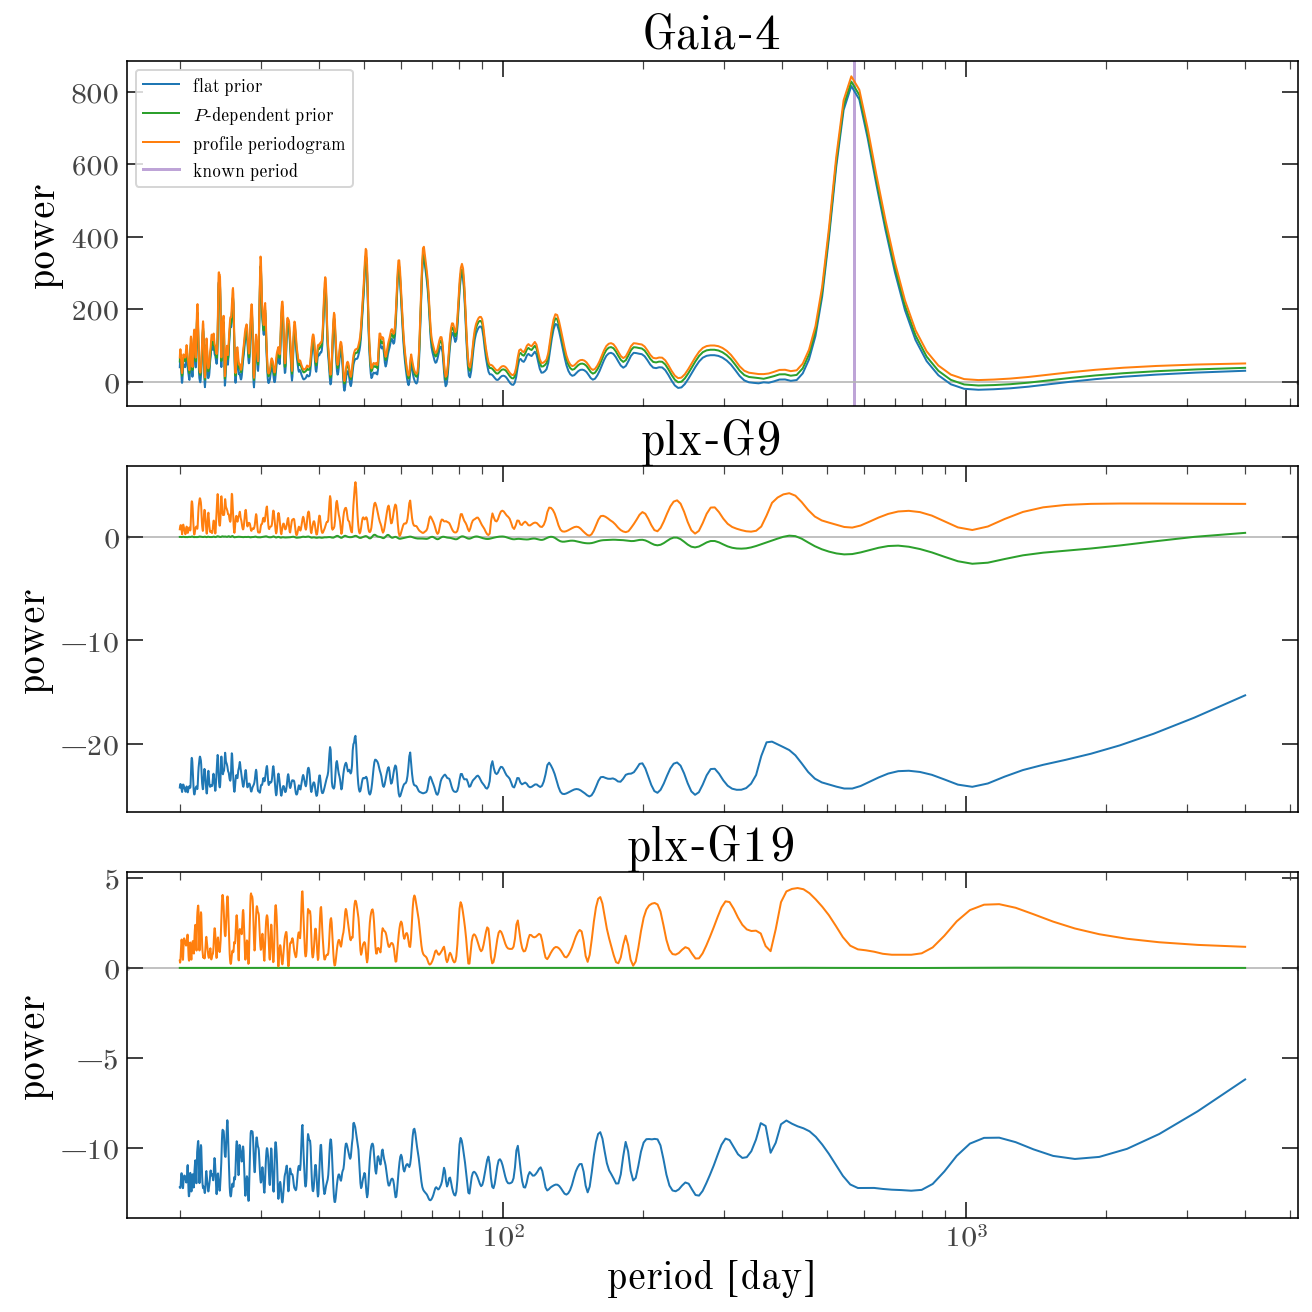

In [26]:
pgram_colors = {
    "flat prior": "tab:blue",
    "$P$-dependent prior": "tab:green",
    "profile periodogram": "tab:orange",
}

fig, axes = plt.subplots(3, 1, figsize=(9, 9), layout="constrained", sharex=True)
for ax, (name, pgrams) in zip(axes, gaia_pgrams.items(), strict=True):
    for label, res in pgrams.items():
        ax.plot(
            ustrip("day", res.period),
            res.delta_ln_likelihood,
            color=pgram_colors[label],
            lw=1,
            marker="",
            label=label,
        )
    ax.axhline(0.0, color="0.7", lw=0.8, zorder=0)

    known_period = gaia_data[name][2]
    if np.isfinite(known_period):
        ax.axvline(
            known_period,
            color="tab:purple",
            ls="-",
            lw=1.5,
            label="known period",
            zorder=-10,
            alpha=0.6,
            marker="",
        )

    ax.set(
        xscale="log",
        ylabel=r"power",
        title=name,
    )

axes[0].legend(fontsize=9, loc="upper left")
_ = axes[-1].set_xlabel("period [day]")

Each panel is a different source (i.e. different data) from the Gaia DR4 prerelease, and each colored line is a different periodogram choice.

**Gaia-4**: All three periodograms show a clear and dominant peak at ~564 days, close to the known ~571 day period. Apart from an offset, the structure of the periodograms is nearly identical. This is the same point as we saw above in our demonstrations with radial velocity data: when the period is well determined, neither the choice of statistic (profile vs. marginalized) nor the choice of prior changes the periodogram interpretation. 

**plx-G9**: Here the flat prior (constant amplitude) periodogram (blue line) is negative at every trial period. This is because of the Occam factor, and the interpretation here is that the linear motion / standard astrometric solution model is sufficient for describing the data. Adding the additional sinusoidal terms to the design matrix don't improve things more than the cost of adding the additional free parameters. The periodogram with the period-dependent prior instead sits near zero, and dipping to negative values. This is because a $10\,M_\mathrm{Jup}$ companion at this parallax would produce a wobble of about 0.01 mas whereas the per-transit uncertainties are ~0.035 mas. So the prior is narrow enough that the orbit columns don't help or hurt relative to the standard astrometric model. The profile periodogram is again >0 at all periods with a highest peak around 48 days, but this is well below the FAP threshold for this grid.

**plx-G19**: This is similar to the case of plx-G9 but more extreme. This star is very faint, with per-transit uncertainties around ~0.66 mas, so the expected signal of a ~10 Mjup companion is only 0.007 mas, which is 100 times below the noise level. The period-dependent periodogram is therefore almost completely flat, which says that the data are inconclusive for finding an exoplanet-mass companion at any period. The profile periodogram again shows spurious structure with several modes of comparable amplitude.

These examples demonstrate that a marginalized periodogram provide some capacity for interpretation that we can't get natively from a profile periodogram. A flat marginalized periodogram (no significant peaks as a function of period) means that the data don't have capacity to answer the question. 
A fully negative periodogram means that the trial periods are actively disfavored relative to having no companion at all at the amplitude scale set by the prior.

## Conclusions and Next steps

Where the amplitudes (linear parameters) are well constrained, the marginal and profile periodograms tell you the same thing about the period of a signal in your data. 
However, the marginalized periodogram has two benefits over the more classical profile (Lomb–Scargle) type periodogram: (1) the periodogram power provides immediate model selection interpretation as a log Bayes factor, and (2) the marginal periodogram can be used with a prior on the amplitudes (linear parameters), and that prior can depend on period in a way to build in physical knowledge about the systems you are searching for. 

One final note here is that everything we've done in this note has assumed that the reported uncertainties on the data are correct. 
For real data, this is often not the case.
To account for this when modeling the data and sampling the posterior, we can add a "jitter" parameter that inflates the uncertainties, but we currently do not support this for periodograms (as it would have to be a nonlinear parameter).

In `harv`, the usual next step is to turn the periodogram into an interim period prior for the rejection sampler with {py:func}`~harv.periodogram.attach_interim_period_prior`, so that prior samples concentrate near the periods the data prefer.